# Neural Super-Sampling on Kaggle: Rep-TNSR (GPU T4 x2)

**Goal.** Train and evaluate the Rep-TNSR super-resolution trunk described in `RESEARCH.md` (section 6) at 3x scale (for example 640x360 to 1920x1080), using only Kaggle-hosted datasets, within an 8 hour end-to-end budget on two Tesla T4 GPUs.

**Approach.**

1. Discover the attached datasets under `/kaggle/input` with a capped, randomised directory walk (a full walk of the 540K-file inputs took 15 minutes in the previous run).
2. Drop degraded copies (LR, bicubic, blurred, `x2`/`x3`/`x4` folders) and non-colour passes, so only clean high-resolution frames are used as targets.
3. Split by sequence or image group with a deterministic hash (no frame of a validation sequence is ever trained on). Set5, Set14, B100, Urban100, Manga109 and Vid4 are test-only.
4. Decode once into a uint8 patch cache in `/kaggle/working/cache` (memory-mapped, shared by both GPU processes), so training is never limited by the 4 CPU cores.
5. Train with DistributedDataParallel (one process per T4), FP16 autocast, EMA weights, and a learning-rate schedule driven by a fixed wall-clock budget, so the run always finishes on time.
6. Fuse every multi-branch block into a single 3x3 convolution, verify parity, evaluate on the benchmarks and Vid4 using both GPUs, measure latency, export ONNX, and zip all outputs.

**Model.** Rep-TNSR v2 "Ultra" tier with RGB input (no G-buffers exist on Kaggle): 6 reparameterisable blocks of 24 channels, a 3x3 projection to 27 channels and a pixel shuffle, about 32.7K parameters after fusion. Loss is Charbonnier plus 0.3 x edge loss, matching the spatial warm-up phase of the research curriculum.

**Datasets** (attach with **Add Input**; any missing one is skipped and its share redistributed):

| Kaggle dataset | Role |
| :--- | :--- |
| `soumikrakshit/div2k-high-resolution-images` | Training (2K stills) |
| `daehoyang/flickr2k` | Training (2K stills) |
| `itzloghotxd/df2k-ost` | Training (stills, duplicates of DIV2K and Flickr2K removed by file name) |
| `yashchoudhary/realsr-v3` | Training (HR side of real camera pairs only) |
| `amithkesavmrajagiri/reds-dataset` | Training (720p video frames) |
| `wangsally/vimeo-90k-7` | Training (448x256 video frames) |
| `chenshu123/vimeo-triplet` | Training (448x256 video frames) |
| `artemmmtry/mpi-sintel-dataset` | Training (clean and final passes only) |
| `jesucristo/super-resolution-benchmarks` | Test only: Set5, Set14, B100, Urban100, Manga109 |
| `uom200647r/vid4-dataset` | Test only: Vid4 video sequences and temporal metrics |

The REDS toy dataset is not used: its documented 128x128 HR patches are smaller than the 240-pixel cache patches. FlyingChairs is not used here; the frame-generation notebook covers motion data.

**Hardware.** Kaggle GPU T4 x2 (2 x 15 GB VRAM, fp16 tensor cores, no fast bf16), 4 CPU cores, about 30 GB RAM, 20 GB of saved disk in `/kaggle/working`.

**Required Kaggle settings.** Accelerator: GPU T4 x2. Internet: not needed (nothing is installed or downloaded). Attach the datasets above. Use **Save Version > Save & Run All** for an unattended run.

**Run budget** (upper bounds enforced in code; the configuration cell holds the numbers):

| Stage | Budget |
| :--- | :--- |
| Setup, discovery, EDA | about 10 min |
| Patch cache build | at most 25 min |
| Training (DDP, both GPUs) | 5 h, cut automatically if earlier stages ran long |
| Evaluation, Vid4, latency, export, zip | about 30 min (55 min reserved) |
| **Total** | **about 6.5 h, hard ceiling 8 h** |

Set `QUICK_RUN = True` in the configuration cell for a smoke test of about 30 minutes.

**Outputs** in `/kaggle/working/`:

```text
code/          generated library and DDP training script
weights/       sr_last.pt, sr_best_ema.pt, sr_fused.pt, rep_tnsr_fused.onnx
plots/         every figure shown in the notebook, as PNG
metrics/       JSON and CSV metrics (hardware, catalogue, training history, benchmarks, latency, summary)
logs/          notebook log and the full DDP training log
predictions/   sample super-resolved images
outputs.zip    everything above, created by the final cell
```

The temporary patch cache (`cache/`) is deleted before zipping.

## 1. Setup

Imports, output folders, a logger that writes to the screen and to `logs/notebook.log`, a `stage` timer that records the run time of every stage for the final report, and a `show` helper that displays a figure once and saves it to `plots/`. `NOTEBOOK_START` anchors the 8 hour budget: later cells shorten training if earlier stages ran long.

In [1]:
import copy
import json
import logging
import math
import os
import random
import shutil
import subprocess
import sys
import threading
import time
import zipfile
from concurrent.futures import ThreadPoolExecutor, as_completed
from contextlib import contextmanager
from multiprocessing import Pool
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import torch
import torch.nn.functional as F
from IPython.display import FileLink, display
from PIL import Image
from tqdm.auto import tqdm

NOTEBOOK_START = time.time()
INPUT_ROOT = Path("/kaggle/input")
WORK = Path("/kaggle/working")
DIRS = {
    name: WORK / name
    for name in ["code", "cache", "weights", "plots", "metrics", "logs", "predictions"]
}
for folder in DIRS.values():
    folder.mkdir(parents=True, exist_ok=True)

log = logging.getLogger("rep_tnsr")
log.setLevel(logging.INFO)
log.handlers.clear()
for handler in (
    logging.StreamHandler(sys.stdout),
    logging.FileHandler(DIRS["logs"] / "notebook.log"),
):
    handler.setFormatter(logging.Formatter("%(asctime)s | %(message)s", "%H:%M:%S"))
    log.addHandler(handler)

STAGE_TIMES = {}


@contextmanager
def stage(name):
    start = time.time()
    log.info("start: %s", name)
    try:
        yield
    finally:
        STAGE_TIMES[name] = time.time() - start
        log.info(
            "done: %s in %.1f min (run total %.2f h)",
            name,
            STAGE_TIMES[name] / 60,
            (time.time() - NOTEBOOK_START) / 3600,
        )


def show(fig, name):
    fig.savefig(DIRS["plots"] / f"{name}.png", dpi=130, bbox_inches="tight")
    display(fig)
    plt.close(fig)


def save_json(obj, name):
    with open(DIRS["metrics"] / name, "w") as f:
        json.dump(obj, f, indent=2, default=str)


log.info("output folders ready under %s", WORK)

13:56:31 | output folders ready under /kaggle/working


## 2. Hardware check

Detects the GPUs, CPU cores, RAM and free disk at runtime (nothing is hard-coded), prints them, saves `metrics/hardware.json`, and stops the run early if two GPUs are not visible, because the training stage launches one process per GPU. Expected output: two Tesla T4 rows with about 15 GB each.

In [2]:
N_GPUS = torch.cuda.device_count()
gpu_rows = []
for i in range(N_GPUS):
    props = torch.cuda.get_device_properties(i)
    gpu_rows.append(
        {
            "gpu": i,
            "name": props.name,
            "vram_gb": round(props.total_memory / 2**30, 2),
            "multiprocessors": props.multi_processor_count,
            "compute_capability": f"{props.major}.{props.minor}",
        }
    )
vm, disk = psutil.virtual_memory(), shutil.disk_usage(WORK)
HARDWARE = {
    "gpus": N_GPUS,
    "cpu_count": os.cpu_count(),
    "ram_total_gb": round(vm.total / 2**30, 1),
    "ram_available_gb": round(vm.available / 2**30, 1),
    "disk_free_gb_working": round(disk.free / 2**30, 1),
    "python": sys.version.split()[0],
    "torch": torch.__version__,
    "cuda": torch.version.cuda,
    "cudnn": torch.backends.cudnn.version(),
    "gpu_list": gpu_rows,
}
print(pd.DataFrame(gpu_rows).to_string(index=False))
print(pd.Series({k: v for k, v in HARDWARE.items() if k != "gpu_list"}).to_string())
save_json(HARDWARE, "hardware.json")
assert (
    N_GPUS >= 2
), "Two GPUs are required. Choose Settings > Accelerator > GPU T4 x2 and run again."

 gpu     name  vram_gb  multiprocessors compute_capability
   0 Tesla T4    14.56               40                7.5
   1 Tesla T4    14.56               40                7.5
gpus                               2
cpu_count                          4
ram_total_gb                    31.3
ram_available_gb                29.8
disk_free_gb_working            19.5
python                       3.13.15
torch                   2.11.0+cu128
cuda                            12.8
cudnn                          91900


## 3. Configuration

Every tunable value lives here: seeds, scale, model tier, patch sizes, cache size, time budgets, optimiser settings and the dataset registry.

* `cache_patch` 240 / `hr_patch` 192: cached patches are 240 px so each batch can take a random 192 px crop (64 px LR input at 3x), adding translation variety on top of the 8 flips and transposes applied on the GPU.
* `cache_gb` caps the patch cache; the build cell lowers it further if RAM or disk is short.
* `train_hours` is the wall-clock training budget. The learning rate follows warm-up plus cosine decay over this budget, so training always ends with a fully decayed rate. `eval_reserve_h` keeps time for evaluation and export inside `RUN_BUDGET_H`.
* `base_lr` is defined for an effective batch of `base_batch`; the probe in section 10 picks the batch and the rate is scaled by the square root of the ratio.
* `max_batch_per_gpu` caps the probed batch: past GPU saturation a larger batch only reduces the number of optimiser updates inside a fixed time budget.
* `quota` is each training dataset's share of the patch cache (renormalised over the datasets that are attached); `group_level` sets the split unit (0 image, 1 sequence folder, 2 video folder); `max_ppi` caps patches per image so a few large images cannot dominate.

In [3]:
QUICK_RUN = False
RUN_BUDGET_H = 8.0

CFG = {
    "seed": 42,
    "scale": 3,
    "tier": "ultra",
    "cache_patch": 240,
    "hr_patch": 192,
    "cache_gb": 7.0,
    "cache_build_min": 25,
    "val_patches": 2048,
    "val_permille": 30,
    "min_patch_std": 6.0,
    "list_cap_files": 40000,
    "eda_samples": 600,
    "val_full_images": 150,
    "train_hours": 5.0,
    "eval_reserve_h": 0.9,
    "base_lr": 5e-4,
    "base_batch": 256,
    "max_lr": 2e-3,
    "min_lr": 1e-6,
    "warmup_frac": 0.02,
    "weight_decay": 1e-4,
    "w_edge": 0.3,
    "ema_decay": 0.999,
    "grad_clip": 1.0,
    "batch_candidates": [64, 128, 256, 384, 512, 768, 1024, 1536],
    "max_batch_per_gpu": 512,
    "vram_headroom": 0.10,
    "val_interval_min": 10,
    "progress_interval_s": 15,
    "sync_every": 10,
    "val_batch": 64,
    "latency_iters": 200,
    "latency_sizes": [[360, 640], [720, 1280]],
}
SOURCES = [
    {
        "name": "div2k",
        "slug": "soumikrakshit/div2k-high-resolution-images",
        "role": "train",
        "group_level": 0,
        "quota": 0.12,
        "max_ppi": 24,
    },
    {
        "name": "flickr2k",
        "slug": "daehoyang/flickr2k",
        "role": "train",
        "group_level": 0,
        "quota": 0.22,
        "max_ppi": 16,
    },
    {
        "name": "df2k_ost",
        "slug": "itzloghotxd/df2k-ost",
        "role": "train",
        "group_level": 0,
        "quota": 0.16,
        "max_ppi": 8,
    },
    {
        "name": "realsr_v3",
        "slug": "yashchoudhary/realsr-v3",
        "role": "train",
        "group_level": 0,
        "quota": 0.05,
        "max_ppi": 8,
    },
    {
        "name": "reds",
        "slug": "amithkesavmrajagiri/reds-dataset",
        "role": "train",
        "group_level": 1,
        "quota": 0.15,
        "max_ppi": 2,
    },
    {
        "name": "vimeo_septuplet",
        "slug": "wangsally/vimeo-90k-7",
        "role": "train",
        "group_level": 2,
        "quota": 0.12,
        "max_ppi": 1,
    },
    {
        "name": "vimeo_triplet",
        "slug": "chenshu123/vimeo-triplet",
        "role": "train",
        "group_level": 2,
        "quota": 0.10,
        "max_ppi": 1,
    },
    {
        "name": "sintel",
        "slug": "artemmmtry/mpi-sintel-dataset",
        "role": "train",
        "group_level": 1,
        "quota": 0.08,
        "max_ppi": 2,
    },
    {
        "name": "sr_benchmarks",
        "slug": "jesucristo/super-resolution-benchmarks",
        "role": "test",
        "group_level": 0,
    },
    {
        "name": "vid4",
        "slug": "uom200647r/vid4-dataset",
        "role": "video_test",
        "group_level": 1,
    },
]
if QUICK_RUN:
    CFG.update(
        {
            "cache_gb": 0.6,
            "cache_build_min": 5,
            "val_patches": 256,
            "list_cap_files": 4000,
            "eda_samples": 150,
            "val_full_images": 20,
            "train_hours": 10 / 60,
            "eval_reserve_h": 0.5,
            "val_interval_min": 3,
            "latency_iters": 50,
        }
    )

random.seed(CFG["seed"])
np.random.seed(CFG["seed"])
torch.manual_seed(CFG["seed"])
torch.backends.cudnn.benchmark = True
save_json(
    {
        "quick_run": QUICK_RUN,
        "run_budget_h": RUN_BUDGET_H,
        "cfg": CFG,
        "sources": SOURCES,
    },
    "config.json",
)
print(pd.Series(CFG).to_string())

seed                                                          42
scale                                                          3
tier                                                       ultra
cache_patch                                                  240
hr_patch                                                     192
cache_gb                                                     7.0
cache_build_min                                               25
val_patches                                                 2048
val_permille                                                  30
min_patch_std                                                6.0
list_cap_files                                             40000
eda_samples                                                  600
val_full_images                                              150
train_hours                                                  5.0
eval_reserve_h                                               0.9
base_lr                  

## 4. Library: model, losses, metrics

Written to `code/sr_lib.py` so that the notebook and the DDP training processes import the same code.

* `RepConvBlock`: 3x3 conv + 1x1 conv + identity + fixed Sobel-x, Sobel-y and Laplacian filters each followed by a learnable 1x1 projection, then PReLU. All branches are linear, so `fused_conv` folds them into one 3x3 kernel and bias.
* `RepTNSR`: the blocks, a 3x3 projection to 3 x scale^2 channels plus an input-repeat residual (each output sub-pixel starts from the nearest LR colour), and a pixel shuffle.
* Losses: Charbonnier (epsilon 1e-3) and an L1 loss on central-difference gradients.
* Degradation: anti-aliased bicubic downsampling to an exact `H/s x W/s` size (passing `size` avoids the off-by-one that `scale_factor=1/3` can produce).
* Metrics follow the usual SR protocol: BT.601 luma (Y), outputs rounded to 8-bit levels, `scale` border pixels shaved, PSNR and SSIM (11x11 Gaussian, sigma 1.5).

In [4]:
%%writefile /kaggle/working/code/sr_lib.py
"""Rep-TNSR super-resolution library: model, reparameterisation, losses, metrics and degradation."""
import copy

import torch
import torch.nn as nn
import torch.nn.functional as F

SOBEL_X = [[-1.0, 0.0, 1.0], [-2.0, 0.0, 2.0], [-1.0, 0.0, 1.0]]
SOBEL_Y = [[-1.0, -2.0, -1.0], [0.0, 0.0, 0.0], [1.0, 2.0, 1.0]]
LAPLACIAN = [[0.0, 1.0, 0.0], [1.0, -4.0, 1.0], [0.0, 1.0, 0.0]]

TIERS = {
    "performance": {"channels": 16, "blocks": 4},
    "quality": {"channels": 20, "blocks": 4},
    "ultra": {"channels": 24, "blocks": 6},
}


class RepConvBlock(nn.Module):
    """Training-time multi-branch block that collapses into one 3x3 convolution plus PReLU.

    Branches: 3x3 conv, 1x1 conv, identity (when in == out), and fixed Sobel-x, Sobel-y and
    Laplacian depthwise filters followed by a learnable 1x1 projection. Filtering before the
    projection keeps the fusion exact, including at zero-padded borders.
    """

    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.in_ch, self.out_ch = in_ch, out_ch
        self.conv3 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 1)
        kernels = torch.tensor([SOBEL_X, SOBEL_Y, LAPLACIAN]).unsqueeze(1)
        self.register_buffer("edge_dw", kernels.repeat(in_ch, 1, 1, 1), persistent=False)
        self.edge_pw = nn.Conv2d(3 * in_ch, out_ch, 1)
        self.act = nn.PReLU(out_ch)
        self.fused = None

    def forward(self, x):
        if self.fused is not None:
            return self.act(self.fused(x))
        out = self.conv3(x) + self.conv1(x)
        edges = F.conv2d(x, self.edge_dw.to(x.dtype), padding=1, groups=self.in_ch)
        out = out + self.edge_pw(edges)
        if self.in_ch == self.out_ch:
            out = out + x
        return self.act(out)

    @torch.no_grad()
    def fused_conv(self):
        weight = self.conv3.weight.detach().clone()
        bias = self.conv3.bias.detach().clone()
        weight += F.pad(self.conv1.weight, [1, 1, 1, 1])
        bias += self.conv1.bias
        pointwise = self.edge_pw.weight[:, :, 0, 0].reshape(self.out_ch, self.in_ch, 3)
        weight += torch.einsum("oik,khw->oihw", pointwise, self.edge_dw[:3, 0].to(pointwise.dtype))
        bias += self.edge_pw.bias
        if self.in_ch == self.out_ch:
            idx = torch.arange(self.out_ch, device=weight.device)
            weight[idx, idx, 1, 1] += 1.0
        conv = nn.Conv2d(self.in_ch, self.out_ch, 3, padding=1).to(weight.device, weight.dtype)
        conv.weight.copy_(weight)
        conv.bias.copy_(bias)
        return conv

    def convert_to_fused(self):
        conv = self.fused_conv()
        del self.conv3, self.conv1, self.edge_pw, self.edge_dw
        self.fused = conv


class RepTNSR(nn.Module):
    """Rep-TNSR v2 trunk: N RepConv blocks in LR space, 3x3 projection to 3*s^2, pixel shuffle.

    The input colour is repeated s^2 times and added before the pixel shuffle (ECBSR-style
    nearest-neighbour residual), so the network only learns the high-frequency correction.
    """

    def __init__(self, in_ch=3, channels=24, blocks=6, scale=3):
        super().__init__()
        self.scale = scale
        self.blocks = nn.ModuleList([RepConvBlock(in_ch if i == 0 else channels, channels) for i in range(blocks)])
        self.conv_out = nn.Conv2d(channels, 3 * scale * scale, 3, padding=1)
        self.shuffle = nn.PixelShuffle(scale)

    def forward(self, x):
        feat = x
        for block in self.blocks:
            feat = block(feat)
        sub = self.scale * self.scale
        residual = torch.cat([x[:, c:c + 1].expand(-1, sub, -1, -1) for c in range(3)], dim=1)
        return self.shuffle(self.conv_out(feat) + residual)

    def fused_copy(self):
        fused = copy.deepcopy(self).eval()
        for block in fused.blocks:
            block.convert_to_fused()
        return fused


def build_model(tier, scale, in_ch=3):
    spec = TIERS[tier]
    return RepTNSR(in_ch=in_ch, channels=spec["channels"], blocks=spec["blocks"], scale=scale)


def count_params(model):
    return sum(p.numel() for p in model.parameters())


def fused_macs_per_lr_pixel(in_ch, channels, blocks, scale):
    """Multiply-accumulates per LR pixel of the fused network (convolutions only)."""
    return in_ch * channels * 9 + (blocks - 1) * channels * channels * 9 + channels * 3 * scale * scale * 9


def charbonnier(pred, target, eps=1e-3):
    return torch.sqrt((pred - target) ** 2 + eps * eps).mean()


def edge_loss(pred, target):
    """L1 distance between central-difference gradients in x and y."""
    def grads(img):
        return img[..., :, 2:] - img[..., :, :-2], img[..., 2:, :] - img[..., :-2, :]

    (pred_x, pred_y), (gt_x, gt_y) = grads(pred), grads(target)
    return (pred_x - gt_x).abs().mean() + (pred_y - gt_y).abs().mean()


def bicubic_down(hr, scale):
    """Anti-aliased bicubic downsampling; HR height and width must be divisible by scale."""
    h, w = hr.shape[-2:]
    lr = F.interpolate(hr, size=(h // scale, w // scale), mode="bicubic", antialias=True, align_corners=False)
    return lr.clamp_(0.0, 1.0)


def bicubic_up(lr, scale):
    h, w = lr.shape[-2:]
    return F.interpolate(lr, size=(h * scale, w * scale), mode="bicubic", align_corners=False).clamp_(0.0, 1.0)


def random_dihedral(x):
    """Independent random flip and transpose per sample (the 8 dihedral variants of a square patch)."""
    flags = torch.rand(x.shape[0], 3, device=x.device) < 0.5
    x = torch.where(flags[:, 0, None, None, None], x.flip(-1), x)
    x = torch.where(flags[:, 1, None, None, None], x.flip(-2), x)
    return torch.where(flags[:, 2, None, None, None], x.transpose(-1, -2), x)


def quantize(x):
    return (x.clamp(0.0, 1.0) * 255.0).round() / 255.0


def rgb_to_y(x):
    """ITU-R BT.601 luma used by SR benchmarks, returned on a [0, 1] scale."""
    return (16.0 + 65.481 * x[:, 0:1] + 128.553 * x[:, 1:2] + 24.966 * x[:, 2:3]) / 255.0


def shave(x, border):
    return x[..., border:-border, border:-border] if border > 0 else x


def psnr(a, b, border=0):
    """Per-image PSNR in dB for tensors in [0, 1]."""
    mse = ((shave(a, border).float() - shave(b, border).float()) ** 2).mean(dim=(1, 2, 3))
    return 10.0 * torch.log10(1.0 / mse.clamp_min(1e-10))


def _gaussian_window(channels, size=11, sigma=1.5, device=None):
    coords = torch.arange(size, dtype=torch.float32, device=device) - size // 2
    g = torch.exp(-(coords ** 2) / (2 * sigma * sigma))
    g = g / g.sum()
    return (g[:, None] * g[None, :]).expand(channels, 1, size, size).contiguous()


def ssim(a, b, border=0):
    """Per-image SSIM (11x11 Gaussian window, sigma 1.5, valid region only)."""
    a, b = shave(a, border).float(), shave(b, border).float()
    channels = a.shape[1]
    window = _gaussian_window(channels, device=a.device)
    mu_a = F.conv2d(a, window, groups=channels)
    mu_b = F.conv2d(b, window, groups=channels)
    var_a = F.conv2d(a * a, window, groups=channels) - mu_a ** 2
    var_b = F.conv2d(b * b, window, groups=channels) - mu_b ** 2
    cov = F.conv2d(a * b, window, groups=channels) - mu_a * mu_b
    c1, c2 = 0.01 ** 2, 0.03 ** 2
    score = ((2 * mu_a * mu_b + c1) * (2 * cov + c2)) / ((mu_a ** 2 + mu_b ** 2 + c1) * (var_a + var_b + c2))
    return score.mean(dim=(1, 2, 3))

Writing /kaggle/working/code/sr_lib.py


## 5. Library: dataset discovery and patch extraction

Written to `code/sr_data.py`.

* `find_dataset_root` supports both Kaggle mount layouts: `/kaggle/input/<slug>` and `/kaggle/input/datasets/<owner>/<slug>` (the previous run used the second).
* `sampled_walk` lists at most `list_cap_files` images per dataset, expanding a random directory each step so the sample spans many sequences.
* `is_clean_colour` rejects degraded copies and non-colour passes by path token (`lr`, `bicubic`, `x4`, `blur`, `occlusions`, `flow`, `depth`, other methods' outputs in benchmark mirrors, and so on). For test sets, if any file carries an `HR`/`GT` marker, only marked files are kept.
* `group_key` and `in_holdout` give a deterministic, leak-free train/validation split by image, sequence or video.
* `extract_patches` runs in worker processes: decode one image, return up to `n` random patches, skipping flat patches (luma standard deviation below `min_patch_std`).

In [5]:
%%writefile /kaggle/working/code/sr_data.py
"""Dataset discovery, filtering, splitting and patch extraction for the Kaggle SR notebook."""
import hashlib
import os
import random
import re
from pathlib import Path

import numpy as np
from PIL import Image

IMG_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".webp", ".tif", ".tiff", ".ppm"}
# Path tokens that mark degraded copies (LR, blurred, compressed) or non-colour passes.
LOW_QUALITY_TOKEN = re.compile(r"^(lr\d*|lq|low|lowres|bicubic|bix\d|bdx\d|lrbi|lrbd|x\d|blur|blurred|noisy|compressed|jpeg)$")
NON_COLOUR_TOKENS = {"occlusions", "occlusion", "invalid", "flow", "viz", "mask", "masks", "depth", "albedo",
                     "shading", "disparities", "segmentation", "camdata", "edges", "normals"}
# Benchmark files from SelfExSR-style mirrors also contain other methods' outputs.
METHOD_TOKENS = {"glasner", "scsr", "selfexsr", "kim", "srcnn", "aplus", "a+", "nearest"}
HR_TOKENS = {"hr", "gt", "original", "groundtruth"}


def tokens(text):
    return [t for t in re.split(r"[_\-\s.]+", text.lower()) if t]


def path_tokens(path, root):
    rel = Path(path).relative_to(root)
    parts = list(rel.parts[:-1]) + [Path(rel.parts[-1]).stem]
    return [t for part in parts for t in tokens(part)]


def is_clean_colour(path, root):
    toks = path_tokens(path, root)
    return not any(LOW_QUALITY_TOKEN.match(t) or t in NON_COLOUR_TOKENS or t in METHOD_TOKENS for t in toks)


def has_hr_marker(path, root):
    return any(t in HR_TOKENS for t in path_tokens(path, root))


def find_dataset_root(input_root, owner_slug):
    """Return the mount folder of a Kaggle dataset under either supported layout, or None."""
    owner, slug = owner_slug.split("/")
    input_root = Path(input_root)
    for candidate in (input_root / slug, input_root / "datasets" / owner / slug, input_root / "datasets" / slug):
        if candidate.is_dir():
            return candidate
    for depth_one in input_root.iterdir() if input_root.is_dir() else []:
        if depth_one.is_dir():
            for depth_two in [depth_one] + [p for p in depth_one.iterdir() if p.is_dir()]:
                if depth_two.name == slug:
                    return depth_two
    return None


def sampled_walk(root, max_files, seed):
    """List image files, expanding a random directory from the frontier each step.

    Random frontier expansion samples many sequences early instead of exhausting one branch,
    so a capped listing stays diverse while touching only a fraction of a large mount.
    """
    rng = random.Random(seed)
    frontier, files, dirs_listed = [str(root)], [], 0
    while frontier and len(files) < max_files:
        i = rng.randrange(len(frontier))
        frontier[i], frontier[-1] = frontier[-1], frontier[i]
        current = frontier.pop()
        try:
            entries = list(os.scandir(current))
        except OSError:
            continue
        dirs_listed += 1
        for entry in entries:
            if entry.name.startswith("."):
                continue
            if entry.is_dir(follow_symlinks=False):
                frontier.append(entry.path)
            elif os.path.splitext(entry.name)[1].lower() in IMG_EXTS:
                files.append(entry.path)
    return sorted(files), dirs_listed, len(frontier) == 0


def sequence_name(path):
    """Sequence folder of a video frame, skipping a trailing HR/GT marker folder (calendar/GT/x.png)."""
    parent = Path(path).parent
    return parent.parent.name if parent.name.lower() in HR_TOKENS else parent.name


def canonical_stem(path):
    """Image identity across SelfExSR-style copies: img_001_SRF_3_HR -> img_001."""
    stem = re.sub(r"_srf_\d+", "", Path(path).stem.lower())
    return re.sub(r"_(hr|gt)$", "", stem)


def group_key(path, level):
    """Split unit: 0 = the file itself, 1 = parent folder (sequence), 2 = grandparent (video)."""
    p = Path(path)
    return p.stem if level == 0 else p.parents[level - 1].name


def in_holdout(dataset, key, permille):
    digest = hashlib.md5(f"{dataset}/{key}".encode()).hexdigest()
    return int(digest, 16) % 1000 < permille


def interleave_by_group(files, groups, seed):
    """Round-robin over shuffled groups so a capped selection spans many sequences."""
    rng = random.Random(seed)
    buckets = {}
    for f, g in zip(files, groups):
        buckets.setdefault(g, []).append(f)
    order = list(buckets)
    rng.shuffle(order)
    for g in order:
        rng.shuffle(buckets[g])
    out, depth = [], 0
    while len(out) < len(files):
        for g in order:
            if depth < len(buckets[g]):
                out.append(buckets[g][depth])
        depth += 1
    return out


def image_size(path):
    try:
        with Image.open(path) as im:
            return im.size
    except Exception:
        return None


def extract_patches(task):
    """Worker: decode one image and return up to n random textured uint8 patches of size p."""
    path, n, p, seed, min_std = task
    try:
        with Image.open(path) as im:
            img = np.asarray(im.convert("RGB"))
    except Exception:
        return path, None
    h, w = img.shape[:2]
    if h < p or w < p:
        return path, None
    rng = np.random.default_rng(seed)
    patches = []
    for _ in range(n * 3):
        y, x = int(rng.integers(0, h - p + 1)), int(rng.integers(0, w - p + 1))
        patch = img[y:y + p, x:x + p]
        if patch.mean(axis=2).std() >= min_std:
            patches.append(patch)
            if len(patches) == n:
                break
    return path, np.stack(patches) if patches else None


def load_rgb_modcrop(path, scale):
    with Image.open(path) as im:
        img = np.asarray(im.convert("RGB"))
    h, w = img.shape[:2]
    return img[: h - h % scale, : w - w % scale]

Writing /kaggle/working/code/sr_data.py


## 6. DDP training script

Written to `code/train_sr.py` and launched in section 11 with `torch.distributed.run` (one process per GPU, NCCL backend).

* Data: each rank reads whole batches from the memory-mapped cache through a `DataLoader` with a distributed batch sampler, pinned memory, persistent workers and prefetching. Cropping, flips, transposes and bicubic downsampling run on the GPU.
* Step: FP16 autocast forward, loss in FP32, gradient scaling, clipping at 1.0, AdamW, and an EMA copy of the weights on rank 0.
* Every `sync_every` steps one all-reduce shares elapsed time, the validation flag and per-GPU peak memory, so both ranks use the same learning rate and stop on the same step.
* Every `val_interval_min` minutes rank 0 validates the EMA weights on the held-out patches, saves `sr_last.pt` and, on improvement, `sr_best_ema.pt`, and prints a `ROUND` line. `PROGRESS` lines every `progress_interval_s` seconds feed the notebook progress bar.

In [6]:
%%writefile /kaggle/working/code/train_sr.py
"""DDP training entry point for Rep-TNSR, launched by the notebook through torch.distributed.run.

Rank 0 prints machine-readable lines that the notebook turns into a live progress bar and plots:
PROGRESS {json} every few seconds, ROUND {json} after each validation round, DONE {json} at the end.
"""
import argparse
import copy
import json
import math
import os
import subprocess
import sys
import time
from datetime import timedelta

import numpy as np
import torch
import torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data import BatchSampler, DataLoader, Dataset, DistributedSampler

sys.path.insert(0, os.path.dirname(os.path.abspath(__file__)))
from sr_lib import (bicubic_down, bicubic_up, build_model, charbonnier, edge_loss, psnr,  # noqa: E402
                    quantize, random_dihedral, rgb_to_y, ssim)


class PatchCache(Dataset):
    """Returns whole batches of uint8 patches from a memory-mapped .npy cache, opened lazily per worker."""

    def __init__(self, path, count):
        self.path, self.count, self.data = path, count, None

    def __len__(self):
        return self.count

    def __getitem__(self, indices):
        if self.data is None:
            self.data = np.load(self.path, mmap_mode="r")
        return torch.from_numpy(np.ascontiguousarray(self.data[np.sort(np.asarray(indices))]))


def lr_at(progress, cfg):
    """Linear warm-up then cosine decay, driven by the fraction of the wall-clock budget used."""
    if progress < cfg["warmup_frac"]:
        return cfg["lr"] * max(progress / cfg["warmup_frac"], 0.01)
    t = min(1.0, (progress - cfg["warmup_frac"]) / (1.0 - cfg["warmup_frac"]))
    return cfg["min_lr"] + 0.5 * (cfg["lr"] - cfg["min_lr"]) * (1.0 + math.cos(math.pi * t))


def to_hr(batch, device, crop):
    """uint8 NHWC batch -> random crop (one offset per batch) -> per-sample dihedral -> float NCHW."""
    x = batch.to(device, non_blocking=True).permute(0, 3, 1, 2).float().div_(255.0)
    size = x.shape[-1]
    if crop < size:
        oy, ox = np.random.randint(0, size - crop + 1, size=2)
        x = x[..., oy:oy + crop, ox:ox + crop]
    return random_dihedral(x).contiguous(memory_format=torch.channels_last)


def gpu_utilisation():
    try:
        out = subprocess.run(["nvidia-smi", "--query-gpu=utilization.gpu", "--format=csv,noheader,nounits"],
                             capture_output=True, text=True, timeout=10).stdout
        return [float(v) for v in out.split()]
    except Exception:
        return []


@torch.no_grad()
def validate(model, val_patches, device, scale, batch):
    model.eval()
    rows = {"psnr_y": [], "ssim_y": [], "bicubic_psnr_y": []}
    for i in range(0, val_patches.shape[0], batch):
        hr = torch.from_numpy(val_patches[i:i + batch]).to(device).permute(0, 3, 1, 2).float().div_(255.0)
        lr = bicubic_down(hr, scale)
        with torch.autocast("cuda", dtype=torch.float16):
            sr = model(lr.contiguous(memory_format=torch.channels_last))
        sr_y, hr_y = rgb_to_y(quantize(sr.float())), rgb_to_y(hr)
        rows["psnr_y"].append(psnr(sr_y, hr_y, scale))
        rows["ssim_y"].append(ssim(sr_y, hr_y, scale))
        rows["bicubic_psnr_y"].append(psnr(rgb_to_y(quantize(bicubic_up(lr, scale))), hr_y, scale))
    return {k: torch.cat(v).mean().item() for k, v in rows.items()}


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--config", required=True)
    cfg = json.load(open(parser.parse_args().config))

    dist.init_process_group("nccl", timeout=timedelta(minutes=30))
    rank, world = dist.get_rank(), dist.get_world_size()
    local_rank = int(os.environ["LOCAL_RANK"])
    torch.cuda.set_device(local_rank)
    device = torch.device("cuda", local_rank)
    torch.manual_seed(cfg["seed"])
    np.random.seed(cfg["seed"] + rank)
    torch.backends.cudnn.benchmark = True

    model = build_model(cfg["tier"], cfg["scale"]).to(device).to(memory_format=torch.channels_last)
    ema = copy.deepcopy(model).eval().requires_grad_(False) if rank == 0 else None
    ddp = DDP(model, device_ids=[local_rank], broadcast_buffers=False, gradient_as_bucket_view=True)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg["lr"], betas=(0.9, 0.999), weight_decay=cfg["weight_decay"])
    scaler = torch.amp.GradScaler("cuda")
    val_patches = np.load(cfg["val_cache"])[: cfg["val_count"]] if rank == 0 else None

    sampler = DistributedSampler(range(cfg["train_count"]), num_replicas=world, rank=rank,
                                 shuffle=True, seed=cfg["seed"], drop_last=True)
    loader = DataLoader(PatchCache(cfg["train_cache"], cfg["train_count"]),
                        sampler=BatchSampler(sampler, cfg["batch_per_gpu"], drop_last=True), batch_size=None,
                        num_workers=cfg["workers_per_rank"], pin_memory=True,
                        persistent_workers=True, prefetch_factor=4)

    start = time.time()
    last_val = last_progress = round_start = start
    sync = torch.zeros(2 + world, device=device)
    train_acc = torch.zeros(2, device=device)
    step = epoch = round_steps = round_samples = 0
    best, history, done, lr = -1.0, [], False, lr_at(0.0, cfg)
    while not done:
        sampler.set_epoch(epoch)
        for batch in loader:
            if step % cfg["sync_every"] == 0:
                # One collective agrees on time, validation and per-GPU memory, so every rank
                # uses the same learning rate and stops at the same step.
                sync.zero_()
                if rank == 0:
                    elapsed = time.time() - start
                    sync[0] = elapsed
                    sync[1] = float(elapsed - (last_val - start) >= cfg["val_interval_s"] or elapsed >= cfg["train_seconds"])
                sync[2 + rank] = torch.cuda.max_memory_allocated(device) / 2 ** 30
                dist.all_reduce(sync)
                elapsed, progress = sync[0].item(), min(1.0, sync[0].item() / cfg["train_seconds"])
                mem_gb = [round(v, 2) for v in sync[2:].tolist()]
                lr = lr_at(progress, cfg)
                for group in opt.param_groups:
                    group["lr"] = lr
                if sync[1].item() > 0.5 and round_steps > 0:
                    dist.all_reduce(train_acc)
                    if rank == 0:
                        now = time.time()
                        row = {"round": len(history), "elapsed_min": round(elapsed / 60, 2), "step": step, "epoch": epoch,
                               "train_loss": train_acc[0].item() / (round_steps * world),
                               "train_psnr_rgb": train_acc[1].item() / (round_steps * world),
                               "lr": lr, "img_per_s": round_samples * world / (now - round_start),
                               "mem_gb": mem_gb, "util_pct": gpu_utilisation()}
                        row.update({"val_" + k: v for k, v in validate(ema, val_patches, device, cfg["scale"], cfg["val_batch"]).items()})
                        history.append(row)
                        state = {"model": model.state_dict(), "ema": ema.state_dict(), "optimizer": opt.state_dict(),
                                 "scaler": scaler.state_dict(), "step": step, "elapsed_s": elapsed, "cfg": cfg}
                        torch.save(state, os.path.join(cfg["weights_dir"], "sr_last.pt"))
                        if row["val_psnr_y"] > best:
                            best = row["val_psnr_y"]
                            torch.save({"ema": ema.state_dict(), "round": row["round"], "val_psnr_y": best, "cfg": cfg},
                                       os.path.join(cfg["weights_dir"], "sr_best_ema.pt"))
                        row["best_val_psnr_y"] = best
                        print("ROUND " + json.dumps(row), flush=True)
                        last_val = time.time()
                    dist.barrier()
                    train_acc.zero_()
                    round_steps = round_samples = 0
                    round_start = time.time()
                if progress >= 1.0:
                    done = True
                    break
                if rank == 0 and time.time() - last_progress >= cfg["progress_interval_s"]:
                    print("PROGRESS " + json.dumps({
                        "progress": progress, "step": step, "elapsed_min": round(elapsed / 60, 2), "lr": lr,
                        "loss": train_acc[0].item() / max(round_steps, 1),
                        "img_per_s": round_samples * world / max(time.time() - round_start, 1e-6), "mem_gb": mem_gb}), flush=True)
                    last_progress = time.time()

            hr = to_hr(batch, device, cfg["hr_patch"])
            lr_img = bicubic_down(hr, cfg["scale"]).contiguous(memory_format=torch.channels_last)
            with torch.autocast("cuda", dtype=torch.float16):
                sr = ddp(lr_img)
            sr = sr.float()
            loss = charbonnier(sr, hr) + cfg["w_edge"] * edge_loss(sr, hr)
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
            scaler.step(opt)
            scaler.update()
            if rank == 0:
                decay = min(cfg["ema_decay"], (1 + step) / (10 + step))
                with torch.no_grad():
                    for e, p in zip(ema.parameters(), model.parameters()):
                        e.lerp_(p, 1.0 - decay)
            with torch.no_grad():
                train_acc[0] += loss.detach()
                train_acc[1] += psnr(sr.detach().clamp(0, 1), hr).mean()
            step += 1
            round_steps += 1
            round_samples += hr.shape[0]
        epoch += 1

    if rank == 0:
        with open(os.path.join(cfg["metrics_dir"], "train_history.json"), "w") as f:
            json.dump(history, f, indent=2)
        print("DONE " + json.dumps({"steps": step, "epochs": epoch, "train_seconds": round(time.time() - start, 1),
                                    "best_val_psnr_y": best}), flush=True)
    dist.barrier()
    dist.destroy_process_group()


if __name__ == "__main__":
    main()

Writing /kaggle/working/code/train_sr.py


## 7. Library import and reparameterisation check

Imports the generated modules, then checks on the CPU that a randomly initialised multi-branch model and its fused copy produce the same output (maximum absolute difference should be about 1e-6). The table lists train-time and fused parameter counts and the fused cost per 640x360 frame for each tier, with RGB input as trained here; the 12-channel G-buffer variants in `RESEARCH.md` add input-layer cost only. The bar chart compares fused sizes with the 50K parameter budget.

       tier  blocks  channels  train_params  fused_params  gmac_640x360  gflop_640x360
performance       4        16         14779         11387         2.588           5.18
    quality       4        20         21587         16387         3.732           7.46
      ultra       6        24         44811         32715         7.465          14.93
fusion parity (max abs diff): 3.34e-05


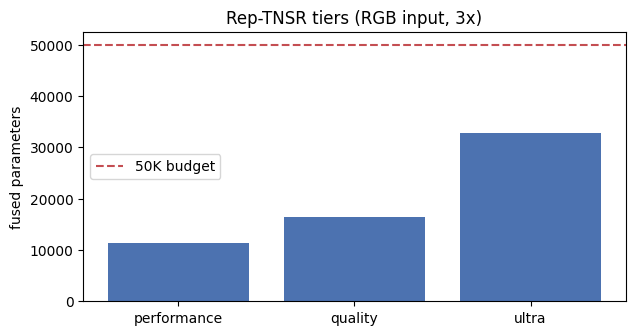

In [7]:
sys.path.insert(0, str(DIRS["code"]))
from sr_data import (
    canonical_stem,
    extract_patches,
    find_dataset_root,
    group_key,
    has_hr_marker,  # noqa: E402
    image_size,
    in_holdout,
    interleave_by_group,
    is_clean_colour,
    load_rgb_modcrop,
    sampled_walk,
    sequence_name,
)
from sr_lib import (
    TIERS,
    bicubic_down,
    bicubic_up,
    build_model,
    charbonnier,
    count_params,
    edge_loss,  # noqa: E402
    fused_macs_per_lr_pixel,
    psnr,
    quantize,
    rgb_to_y,
    ssim,
)

torch.manual_seed(0)
check_model = build_model(CFG["tier"], CFG["scale"]).eval()
check_input = torch.rand(2, 3, 48, 48)
with torch.no_grad():
    parity = (
        (check_model(check_input) - check_model.fused_copy()(check_input))
        .abs()
        .max()
        .item()
    )
tier_rows = []
for tier, spec in TIERS.items():
    train_model = build_model(tier, CFG["scale"])
    macs = (
        fused_macs_per_lr_pixel(3, spec["channels"], spec["blocks"], CFG["scale"])
        * 640
        * 360
    )
    tier_rows.append(
        {
            "tier": tier,
            "blocks": spec["blocks"],
            "channels": spec["channels"],
            "train_params": count_params(train_model),
            "fused_params": count_params(train_model.fused_copy()),
            "gmac_640x360": round(macs / 1e9, 3),
            "gflop_640x360": round(2 * macs / 1e9, 2),
        }
    )
tier_df = pd.DataFrame(tier_rows)
print(tier_df.to_string(index=False))
print(f"fusion parity (max abs diff): {parity:.2e}")
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(tier_df["tier"], tier_df["fused_params"], color="#4C72B0")
ax.axhline(50000, ls="--", color="#C44E52", label="50K budget")
ax.set_ylabel("fused parameters")
ax.set_title("Rep-TNSR tiers (RGB input, 3x)")
ax.legend()
show(fig, "model_tiers")
tier_df.to_csv(DIRS["metrics"] / "model_tiers.csv", index=False)
assert parity < 1e-4, "fused model does not match the multi-branch model"
del check_model, train_model

## 8. Dataset discovery and split

Lists every registered dataset in parallel threads (a progress bar ticks per dataset), filters each file list, assigns splits and builds one catalogue.

* Training datasets: clean colour frames only; groups hashed into `val` (3 percent) or `train`. Still-image duplicates across DIV2K, Flickr2K and DF2K-OST are removed by file name, keeping the first dataset in registry order. If a mirror stores re-cropped copies under new names, the internal validation score can be slightly optimistic; the benchmark sets are unaffected.
* Test datasets: benchmark subsets are labelled from folder names (Set5, Set14, B100, Urban100, Manga109), and copies of the same HR image (SelfExSR-style mirrors repeat it per scale folder) are kept once; Vid4 frames are grouped by sequence.

Expected output: a per-dataset table (whether it was found, files listed, files kept, groups, split counts, listing time), a bar chart, and `metrics/catalogue.csv`. Missing datasets are reported and skipped.

13:56:32 | start: discovery


Listing datasets:   0%|          | 0/10 [00:00<?, ?it/s]

13:59:52 | done: discovery in 3.3 min (run total 0.06 h)
                       role  found  listed  dirs_listed  listing_complete  seconds   kept  test  train   val  groups
dataset                                                                                                             
div2k                 train   True     900            5              True      3.1    900     0    879    21     900
flickr2k              train   True    2650            2              True      9.6   2650     0   2562    88    2650
df2k_ost              train   True   41172           24             False    122.4  10324     0   9996   328   10324
realsr_v3             train   True    3130           20              True     11.0    459     0    442    17     459
reds                  train   True   40000          404             False    185.9  22200     0  21500   700     222
vimeo_septuplet       train   True   40005         5727             False    190.8  40005     0  34433  5572      10
vimeo_t

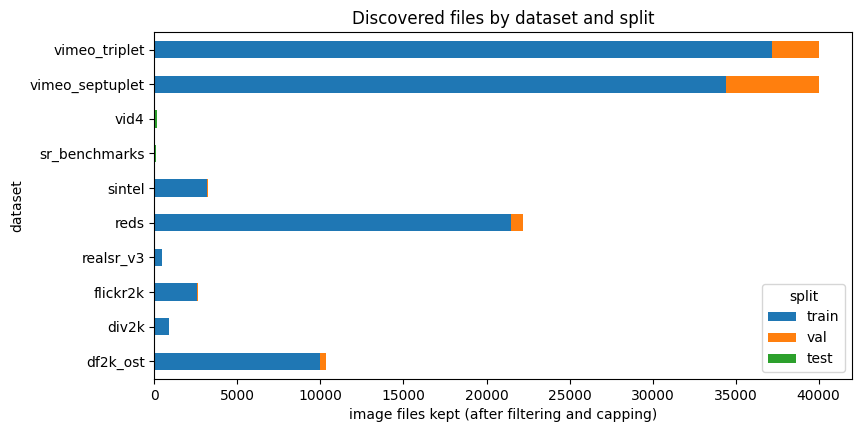

In [8]:
BENCH_NAMES = {
    "set5": "Set5",
    "set14": "Set14",
    "b100": "B100",
    "bsd100": "B100",
    "bsds100": "B100",
    "urban100": "Urban100",
    "manga109": "Manga109",
}


def benchmark_name(path, root):
    for part in Path(path).relative_to(root).parts[:-1]:
        key = part.lower().replace("_", "").replace("-", "")
        for token, name in BENCH_NAMES.items():
            if key.startswith(token):
                return name
    return Path(path).relative_to(root).parts[0]


def list_source(src):
    start = time.time()
    root = find_dataset_root(INPUT_ROOT, src["slug"])
    if root is None:
        return src, None, [], 0, False, time.time() - start
    files, dirs_listed, complete = sampled_walk(
        root, CFG["list_cap_files"], CFG["seed"]
    )
    return src, root, files, dirs_listed, complete, time.time() - start


with stage("discovery"):
    listed = []
    with ThreadPoolExecutor(max_workers=len(SOURCES)) as pool:
        futures = [pool.submit(list_source, src) for src in SOURCES]
        for future in tqdm(
            as_completed(futures), total=len(futures), desc="Listing datasets"
        ):
            listed.append(future.result())
    listed.sort(key=lambda r: SOURCES.index(r[0]))

    records, summary, seen_stems = [], [], set()
    for src, root, files, dirs_listed, complete, seconds in listed:
        row = {
            "dataset": src["name"],
            "role": src["role"],
            "found": root is not None,
            "listed": len(files),
            "dirs_listed": dirs_listed,
            "listing_complete": complete,
            "seconds": round(seconds, 1),
        }
        kept = [f for f in files if is_clean_colour(f, root)] if root else []
        if src["role"] != "train" and any(has_hr_marker(f, root) for f in kept):
            kept = [f for f in kept if has_hr_marker(f, root)]
        for f in kept:
            key = group_key(f, src["group_level"])
            if src["role"] == "train":
                if src["group_level"] == 0:
                    if key in seen_stems:
                        continue
                    seen_stems.add(key)
                split = (
                    "val"
                    if in_holdout(src["name"], key, CFG["val_permille"])
                    else "train"
                )
                subset = src["name"]
            else:
                split = "test"
                subset = benchmark_name(f, root) if src["role"] == "test" else "Vid4"
                if src["role"] == "test":
                    identity = (subset, canonical_stem(f))
                    if identity in seen_stems:
                        continue
                    seen_stems.add(identity)
            records.append(
                {
                    "dataset": src["name"],
                    "role": src["role"],
                    "subset": subset,
                    "group": key,
                    "split": split,
                    "path": f,
                }
            )
        row["kept"] = sum(r["dataset"] == src["name"] for r in records)
        summary.append(row)
    catalogue = pd.DataFrame(
        records, columns=["dataset", "role", "subset", "group", "split", "path"]
    )
    split_counts = catalogue.groupby(["dataset", "split"]).size().unstack(fill_value=0)
    discovery_df = (
        pd.DataFrame(summary).set_index("dataset").join(split_counts).fillna(0)
    )
    discovery_df["groups"] = catalogue.groupby("dataset")["group"].nunique()

print(discovery_df.to_string())
catalogue.to_csv(DIRS["metrics"] / "catalogue.csv", index=False)
discovery_df.to_csv(DIRS["metrics"] / "discovery.csv")
missing = [s["name"] for s, root, *_ in listed if root is None]
if missing:
    log.warning("datasets not attached (skipped): %s", ", ".join(missing))
fig, ax = plt.subplots(figsize=(9, 4.5))
split_counts.reindex(
    columns=[c for c in ["train", "val", "test"] if c in split_counts]
).plot.barh(stacked=True, ax=ax)
ax.set_xlabel("image files kept (after filtering and capping)")
ax.set_title("Discovered files by dataset and split")
show(fig, "dataset_counts")
TRAIN_SOURCES = [
    s
    for s in SOURCES
    if s["role"] == "train" and (catalogue["dataset"] == s["name"]).any()
]
assert (
    TRAIN_SOURCES
), "No training dataset found. Attach at least one training dataset listed in the overview."

## 9. Exploratory analysis

Reads only image headers for a stratified sample of training and validation files (threads, with a progress bar) to show resolution distributions per dataset, then shows one example image per dataset. Images smaller than the 240 px cache patch are reported, because they cannot contribute patches. Expected output: a size summary table, box plots of width, height and megapixels, an example grid, and `metrics/eda_sizes.csv`.

13:59:53 | start: eda


Reading image headers:   0%|          | 0/600 [00:00<?, ?it/s]

13:59:54 | done: eda in 0.0 min (run total 0.06 h)
                  n  median_w  median_h  median_mp  too_small_pct
dataset                                                          
df2k_ost         75     496.0     424.0   0.214400            9.3
div2k            75    2040.0    1356.0   2.766240            0.0
flickr2k         75    2040.0    1356.0   2.766240            0.0
realsr_v3        75    1400.0    1300.0   1.920000            0.0
reds             75    1280.0     720.0   0.921600            0.0
sintel           75    1024.0     436.0   0.446464            0.0
vimeo_septuplet  75     448.0     256.0   0.114688            0.0
vimeo_triplet    75     448.0     256.0   0.114688            0.0


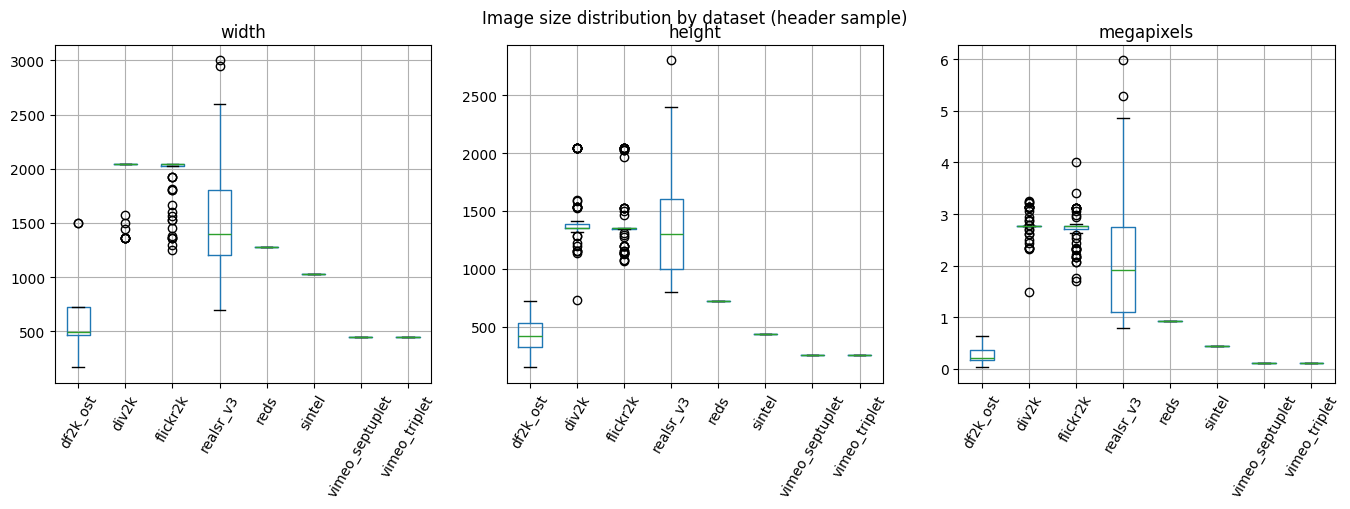

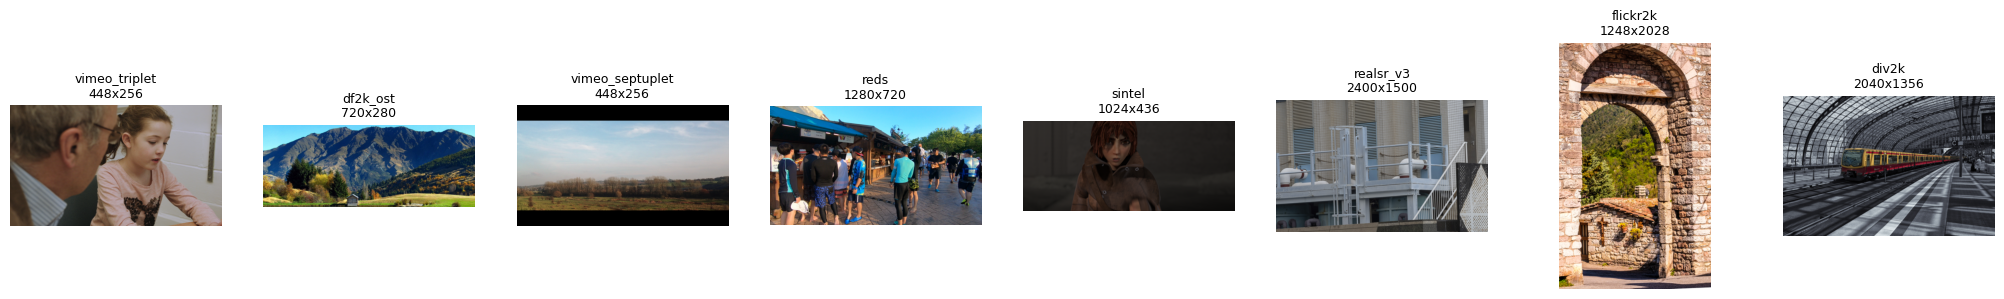

In [9]:
with stage("eda"):
    trainval = catalogue[catalogue["split"].isin(["train", "val"])]
    per_source = max(1, CFG["eda_samples"] // max(1, trainval["dataset"].nunique()))
    eda_sample = (
        trainval.sample(frac=1.0, random_state=CFG["seed"])
        .groupby("dataset")
        .head(per_source)
    )
    with ThreadPoolExecutor(max_workers=16) as pool:
        sizes = list(
            tqdm(
                pool.map(image_size, eda_sample["path"]),
                total=len(eda_sample),
                desc="Reading image headers",
            )
        )
    eda_sample = eda_sample.assign(
        width=[s[0] if s else np.nan for s in sizes],
        height=[s[1] if s else np.nan for s in sizes],
    )
    eda_sample["megapixels"] = eda_sample["width"] * eda_sample["height"] / 1e6
    eda_sample["too_small"] = (
        eda_sample[["width", "height"]].min(axis=1) < CFG["cache_patch"]
    )

size_summary = eda_sample.groupby("dataset").agg(
    n=("path", "size"),
    median_w=("width", "median"),
    median_h=("height", "median"),
    median_mp=("megapixels", "median"),
    too_small_pct=("too_small", "mean"),
)
size_summary["too_small_pct"] = (100 * size_summary["too_small_pct"]).round(1)
print(size_summary.to_string())
eda_sample.drop(columns=["path"]).to_csv(DIRS["metrics"] / "eda_sizes.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, column in zip(axes, ["width", "height", "megapixels"]):
    eda_sample.boxplot(column=column, by="dataset", ax=ax, rot=60)
    ax.set_title(column)
    ax.set_xlabel("")
fig.suptitle("Image size distribution by dataset (header sample)")
show(fig, "eda_sizes")

examples = eda_sample.groupby("dataset").head(1)
fig, axes = plt.subplots(
    1, len(examples), figsize=(3.2 * len(examples), 3.2), squeeze=False
)
for ax, (_, row) in zip(axes[0], examples.iterrows()):
    with Image.open(row["path"]) as im:
        im = im.convert("RGB")
        im.thumbnail((512, 512))
        ax.imshow(im)
    ax.set_title(
        f"{row['dataset']}\n{int(row['width'])}x{int(row['height'])}", fontsize=9
    )
    ax.axis("off")
show(fig, "eda_examples")

## 10. Patch cache build

Decodes training images once, in a process pool over all CPU cores, into `cache/train_patches.npy` (uint8, N x 240 x 240 x 3, memory-mapped) and `cache/val_patches.npy` (one patch per validation image).

* Size: the smallest of `cache_gb`, 35 percent of available RAM (so the page cache can hold it for both GPU processes) and 45 percent of free disk.
* Balance: each dataset gets its quota of patches; files are picked round-robin across sequences, and tasks are shuffled so an early stop keeps the mix.
* Time cap: the build stops after `cache_build_min` minutes and keeps what is filled.

Expected output: live progress bars, a table of patches per dataset against quota, and a bar chart.

13:59:56 | cache target 40509 patches (7.00 GB), 26534 decode tasks
13:59:56 | start: cache_build


Train patches:   0%|          | 0/40509 [00:00<?, ?patch/s]

Validation patches:   0%|          | 0/2048 [00:00<?, ?patch/s]

14:06:34 | done: cache_build in 6.6 min (run total 0.17 h)
                 quota_patches  patches_per_image  images_used  patches_cached  share_pct
dataset                                                                                  
div2k                     4861                  6          811            4862       12.2
flickr2k                  8912                  4         2228            8912       22.4
df2k_ost                  6481                  1         6481            5811       14.6
realsr_v3                 2025                  5          405            2025        5.1
reds                      6076                  1         6076            6075       15.3
vimeo_septuplet           4861                  1         4861            4848       12.2
vimeo_triplet             4051                  1         4051            4051       10.2
sintel                    3241                  2         1621            3242        8.1
train_count        39826.00
train_capacit

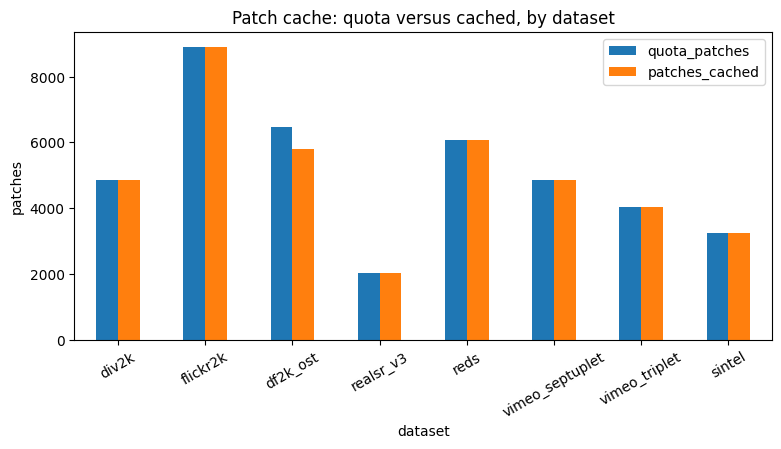

In [10]:
P = CFG["cache_patch"]
patch_bytes = P * P * 3
budget_bytes = min(
    CFG["cache_gb"] * 1e9,
    0.35 * psutil.virtual_memory().available,
    0.45 * shutil.disk_usage(WORK).free,
)
n_target = int(budget_bytes // patch_bytes)
quota_total = sum(s["quota"] for s in TRAIN_SOURCES)
train_cat = catalogue[catalogue["split"] == "train"]
val_cat = catalogue[catalogue["split"] == "val"]

tasks, task_source, plan_rows = [], {}, []
for src in TRAIN_SOURCES:
    rows = train_cat[train_cat["dataset"] == src["name"]]
    files = interleave_by_group(
        rows["path"].tolist(), rows["group"].tolist(), CFG["seed"]
    )
    target = int(round(n_target * src["quota"] / quota_total))
    ppi = int(min(src["max_ppi"], max(1, math.ceil(target / max(1, len(files))))))
    chosen = files[: math.ceil(target / ppi)]
    for path in chosen:
        tasks.append((path, ppi, P, CFG["seed"] + len(tasks), CFG["min_patch_std"]))
        task_source[path] = src["name"]
    plan_rows.append(
        {
            "dataset": src["name"],
            "quota_patches": target,
            "patches_per_image": ppi,
            "images_used": len(chosen),
        }
    )
random.Random(CFG["seed"]).shuffle(tasks)
val_files = interleave_by_group(
    val_cat["path"].tolist(), val_cat["group"].tolist(), CFG["seed"]
)[: CFG["val_patches"]]
val_tasks = [
    (path, 1, P, CFG["seed"] + i, CFG["min_patch_std"])
    for i, path in enumerate(val_files)
]
log.info(
    "cache target %d patches (%.2f GB), %d decode tasks",
    n_target,
    n_target * patch_bytes / 1e9,
    len(tasks),
)


def fill_cache(task_list, capacity, out, desc, deadline):
    filled, failed, counts = 0, 0, {}
    bar = tqdm(total=capacity, desc=desc, unit="patch")
    with Pool(os.cpu_count()) as pool:
        for path, patches in pool.imap_unordered(
            extract_patches, task_list, chunksize=2
        ):
            if patches is None:
                failed += 1
                continue
            take = min(len(patches), capacity - filled)
            out[filled : filled + take] = patches[:take]
            filled += take
            counts[task_source.get(path, "val")] = (
                counts.get(task_source.get(path, "val"), 0) + take
            )
            bar.update(take)
            if filled >= capacity or time.time() > deadline:
                break
    bar.close()
    return filled, failed, counts


with stage("cache_build"):
    deadline = time.time() + CFG["cache_build_min"] * 60
    train_cache = np.lib.format.open_memmap(
        DIRS["cache"] / "train_patches.npy",
        mode="w+",
        dtype=np.uint8,
        shape=(n_target, P, P, 3),
    )
    train_count, train_failed, train_counts = fill_cache(
        tasks, n_target, train_cache, "Train patches", deadline
    )
    train_cache.flush()
    del train_cache
    val_cache = np.zeros((len(val_tasks), P, P, 3), dtype=np.uint8)
    val_count, val_failed, _ = fill_cache(
        val_tasks, len(val_tasks), val_cache, "Validation patches", time.time() + 600
    )
    np.save(DIRS["cache"] / "val_patches.npy", val_cache[:val_count])
    del val_cache

cache_df = pd.DataFrame(plan_rows).set_index("dataset")
cache_df["patches_cached"] = pd.Series(train_counts)
cache_df = cache_df.fillna(0).astype(int)
cache_df["share_pct"] = (100 * cache_df["patches_cached"] / max(1, train_count)).round(
    1
)
print(cache_df.to_string())
CACHE_INFO = {
    "train_count": train_count,
    "train_capacity": n_target,
    "val_count": val_count,
    "patch": P,
    "train_gb": round(train_count * patch_bytes / 1e9, 2),
    "decode_failures": train_failed + val_failed,
}
print(pd.Series(CACHE_INFO).to_string())
save_json(
    {**CACHE_INFO, "per_dataset": cache_df.reset_index().to_dict("records")},
    "cache_summary.json",
)
fig, ax = plt.subplots(figsize=(9, 4))
cache_df[["quota_patches", "patches_cached"]].plot.bar(ax=ax, rot=30)
ax.set_ylabel("patches")
ax.set_title("Patch cache: quota versus cached, by dataset")
show(fig, "cache_composition")
assert (
    train_count >= 1000 and val_count >= 32
), "Patch cache is too small; attach more training data or raise cache_build_min."

## 11. Patch cache inspection

Samples random cached patches to check content and statistics: a grid of 24 patches, per-channel mean and standard deviation, and the distribution of per-patch luma contrast (the flat-patch filter should leave few patches near zero). Expected output: the grid, a statistics table and a histogram.

     mean     std
R  0.1456  0.3261
G  0.1456  0.3050
B  0.1456  0.3057


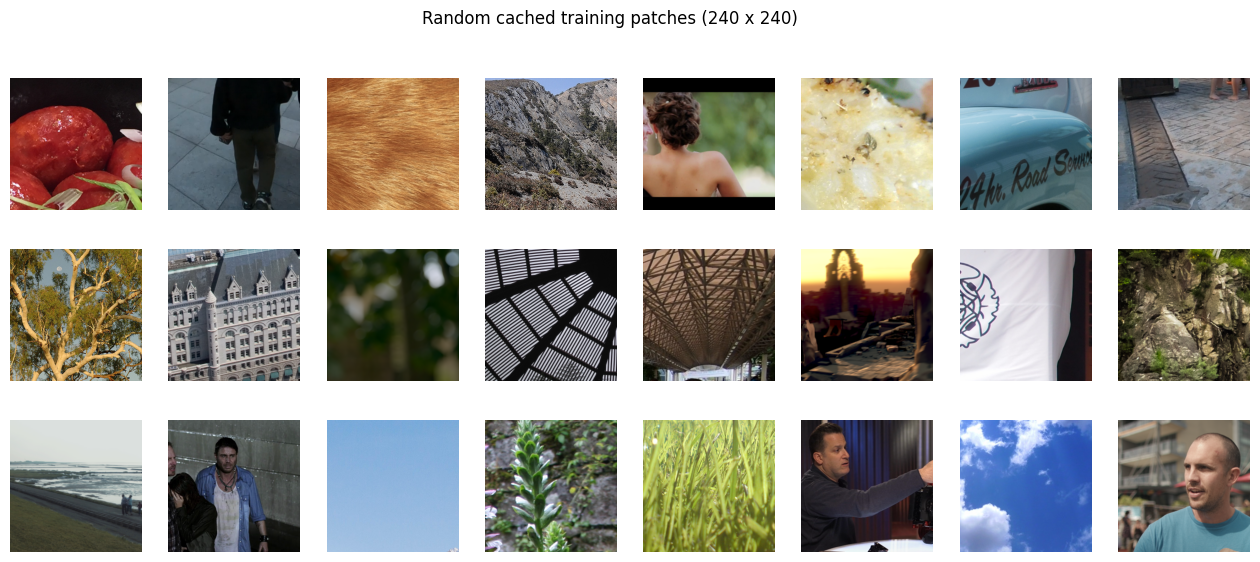

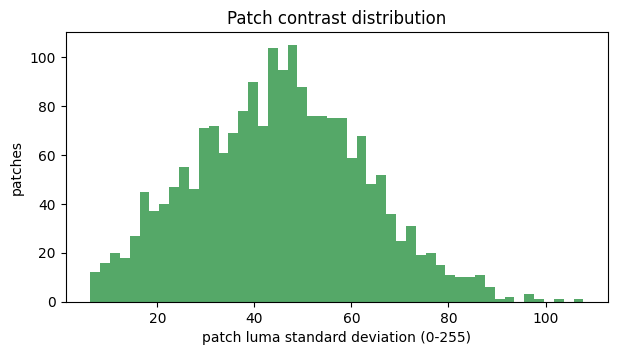

In [11]:
cache_view = np.load(DIRS["cache"] / "train_patches.npy", mmap_mode="r")
rng = np.random.default_rng(CFG["seed"])
sample_idx = np.sort(
    rng.choice(train_count, size=min(2000, train_count), replace=False)
)
sample = np.asarray(cache_view[sample_idx], dtype=np.float32) / 255.0
channel_stats = pd.DataFrame(
    {"mean": sample.mean(axis=(0, 1, 2)), "std": sample.std(axis=(0, 1, 2))},
    index=["R", "G", "B"],
).round(4)
print(channel_stats.to_string())
patch_contrast = sample.mean(axis=3).std(axis=(1, 2)) * 255

fig, axes = plt.subplots(3, 8, figsize=(16, 6.3))
for ax, idx in zip(axes.flat, rng.choice(len(sample), size=24, replace=False)):
    ax.imshow(sample[idx])
    ax.axis("off")
fig.suptitle("Random cached training patches (240 x 240)")
show(fig, "cache_patches")
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(patch_contrast, bins=50, color="#55A868")
ax.set_xlabel("patch luma standard deviation (0-255)")
ax.set_ylabel("patches")
ax.set_title("Patch contrast distribution")
show(fig, "cache_contrast")
channel_stats.to_csv(DIRS["metrics"] / "cache_channel_stats.csv")
del cache_view, sample

## 12. Batch-size probe and training configuration

Runs full training steps (bicubic degradation, FP16 forward, losses, backward, AdamW) on GPU 0 for each candidate batch size, recording peak VRAM and throughput until memory runs out. The chosen batch is the largest that stays under 90 percent of VRAM, capped at `max_batch_per_gpu`. Gradient accumulation stays at 1 because a single step already reaches the target effective batch.

The cell then sets the learning rate (square-root scaling from `base_lr` at `base_batch`), computes the training time actually available inside the 8 hour budget, and writes `code/train_config.json`. Expected output: the probe table, VRAM and throughput plots, and the final training settings.

14:06:47 | start: batch_probe


Batch probe:   0%|          | 0/8 [00:00<?, ?it/s]

14:08:25 | done: batch_probe in 1.6 min (run total 0.20 h)
 batch  fits  peak_vram_pct  img_per_s_one_gpu
    64  True            6.0              474.1
   128  True           12.0              706.9
   256  True           24.0              806.6
   384  True           36.0              837.0
   512  True           48.0              861.5
   768  True           72.0              843.6
  1024  True           96.0              835.9
  1536 False            NaN                NaN
batch_per_gpu            512
effective_batch         1024
learning_rate       1.00e-03
train_minutes          300.0
workers_per_rank           2


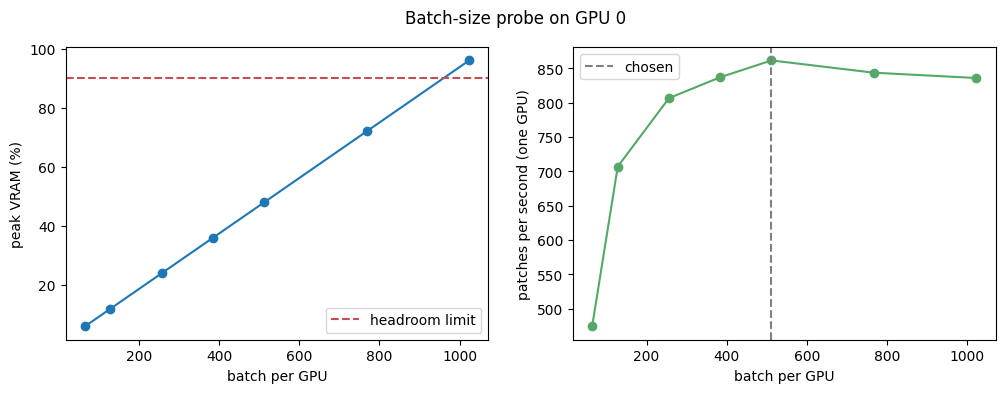

In [12]:
with stage("batch_probe"):
    device0 = torch.device("cuda", 0)
    total_vram = torch.cuda.get_device_properties(0).total_memory
    probe_model = (
        build_model(CFG["tier"], CFG["scale"])
        .to(device0)
        .to(memory_format=torch.channels_last)
    )
    probe_opt = torch.optim.AdamW(probe_model.parameters(), lr=1e-4)
    probe_scaler = torch.amp.GradScaler("cuda")
    probe_rows = []
    for bs in tqdm(CFG["batch_candidates"], desc="Batch probe"):
        hr = lr_in = sr = loss = None
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats(device0)
        try:
            hr = torch.rand(
                bs, 3, CFG["hr_patch"], CFG["hr_patch"], device=device0
            ).contiguous(memory_format=torch.channels_last)
            timings = []
            for _ in range(4):
                torch.cuda.synchronize(device0)
                t0 = time.time()
                lr_in = bicubic_down(hr, CFG["scale"]).contiguous(
                    memory_format=torch.channels_last
                )
                with torch.autocast("cuda", dtype=torch.float16):
                    sr = probe_model(lr_in)
                loss = charbonnier(sr.float(), hr) + CFG["w_edge"] * edge_loss(
                    sr.float(), hr
                )
                probe_opt.zero_grad(set_to_none=True)
                probe_scaler.scale(loss).backward()
                probe_scaler.step(probe_opt)
                probe_scaler.update()
                torch.cuda.synchronize(device0)
                timings.append(time.time() - t0)
            peak = torch.cuda.max_memory_allocated(device0) / total_vram
            probe_rows.append(
                {
                    "batch": bs,
                    "fits": True,
                    "peak_vram_pct": round(100 * peak, 1),
                    "img_per_s_one_gpu": round(bs / np.mean(timings[1:]), 1),
                }
            )
        except torch.cuda.OutOfMemoryError:
            probe_rows.append(
                {
                    "batch": bs,
                    "fits": False,
                    "peak_vram_pct": np.nan,
                    "img_per_s_one_gpu": np.nan,
                }
            )
            break
    del probe_model, probe_opt, probe_scaler, hr, lr_in, sr, loss
    torch.cuda.empty_cache()

probe_df = pd.DataFrame(probe_rows)
print(probe_df.to_string(index=False))
ok = probe_df[
    probe_df["fits"] & (probe_df["peak_vram_pct"] <= 100 * (1 - CFG["vram_headroom"]))
]
assert len(ok), "Even the smallest batch does not fit in GPU memory."
BATCH_PER_GPU = int(min(ok["batch"].max(), CFG["max_batch_per_gpu"]))
EFFECTIVE_BATCH = BATCH_PER_GPU * N_GPUS
LR = min(CFG["max_lr"], CFG["base_lr"] * math.sqrt(EFFECTIVE_BATCH / CFG["base_batch"]))
elapsed_h = (time.time() - NOTEBOOK_START) / 3600
TRAIN_SECONDS = min(
    CFG["train_hours"] * 3600, (RUN_BUDGET_H - CFG["eval_reserve_h"] - elapsed_h) * 3600
)
assert (
    TRAIN_SECONDS > 300
), "Less than 5 minutes left for training inside the run budget."

TRAIN_CFG = {
    "seed": CFG["seed"],
    "tier": CFG["tier"],
    "scale": CFG["scale"],
    "hr_patch": CFG["hr_patch"],
    "train_cache": str(DIRS["cache"] / "train_patches.npy"),
    "train_count": train_count,
    "val_cache": str(DIRS["cache"] / "val_patches.npy"),
    "val_count": val_count,
    "val_batch": CFG["val_batch"],
    "batch_per_gpu": BATCH_PER_GPU,
    "lr": LR,
    "min_lr": CFG["min_lr"],
    "warmup_frac": CFG["warmup_frac"],
    "weight_decay": CFG["weight_decay"],
    "w_edge": CFG["w_edge"],
    "ema_decay": CFG["ema_decay"],
    "grad_clip": CFG["grad_clip"],
    "train_seconds": TRAIN_SECONDS,
    "val_interval_s": CFG["val_interval_min"] * 60,
    "progress_interval_s": CFG["progress_interval_s"],
    "sync_every": CFG["sync_every"],
    "workers_per_rank": max(1, (os.cpu_count() or 2) // N_GPUS),
    "weights_dir": str(DIRS["weights"]),
    "metrics_dir": str(DIRS["metrics"]),
}
TRAIN_CFG_PATH = DIRS["code"] / "train_config.json"
TRAIN_CFG_PATH.write_text(json.dumps(TRAIN_CFG, indent=2))
probe_df.to_csv(DIRS["metrics"] / "batch_probe.csv", index=False)
print(
    pd.Series(
        {
            "batch_per_gpu": BATCH_PER_GPU,
            "effective_batch": EFFECTIVE_BATCH,
            "learning_rate": f"{LR:.2e}",
            "train_minutes": round(TRAIN_SECONDS / 60, 1),
            "workers_per_rank": TRAIN_CFG["workers_per_rank"],
        }
    ).to_string()
)

fit_rows = probe_df[probe_df["fits"]]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(fit_rows["batch"], fit_rows["peak_vram_pct"], "o-")
axes[0].axhline(
    100 * (1 - CFG["vram_headroom"]), ls="--", color="#C44E52", label="headroom limit"
)
axes[0].set_xlabel("batch per GPU")
axes[0].set_ylabel("peak VRAM (%)")
axes[0].legend()
axes[1].plot(fit_rows["batch"], fit_rows["img_per_s_one_gpu"], "o-", color="#55A868")
axes[1].axvline(BATCH_PER_GPU, ls="--", color="grey", label="chosen")
axes[1].set_xlabel("batch per GPU")
axes[1].set_ylabel("patches per second (one GPU)")
axes[1].legend()
fig.suptitle("Batch-size probe on GPU 0")
show(fig, "batch_probe")

## 13. Distributed training on both GPUs

Launches `code/train_sr.py` with `torch.distributed.run --nproc_per_node=2` and streams its output: `PROGRESS` lines drive the progress bar (percent of the time budget, with loss, learning rate, throughput and per-GPU memory), `ROUND` lines print a one-line summary and redraw the training curves in place, and everything is also written to `logs/train_sr.log`.

`NCCL_P2P_DISABLE=1` routes the gradient all-reduce through host memory. The gradients are about 130 KB, so this costs nothing measurable and avoids PCIe peer-to-peer problems on some cloud VMs. Expected output: a progress bar that reaches 100 percent, one summary line every `val_interval_min` minutes, and a final `DONE` line.

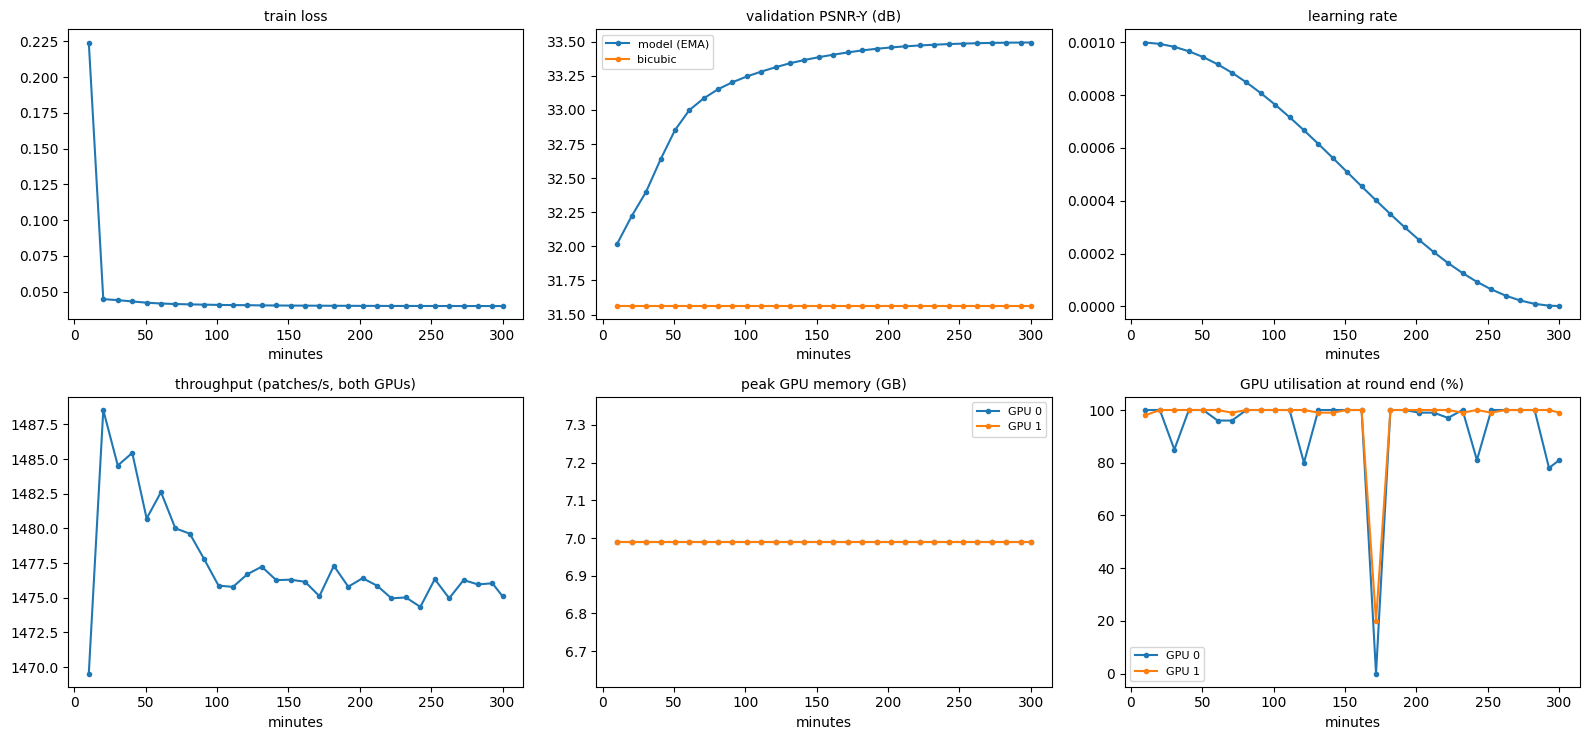

Training (% of time budget):   0%|          | 0.0/100 [00:00<?]

14:08:26 | start: training
round   0 |    10.1 min | loss 0.2243 | val PSNR-Y 32.018 dB (bicubic 31.563) | SSIM-Y 0.8612 | 1470 patches/s | mem GB [6.99, 6.99] | util % [100.0, 98.0]
/usr/local/lib/python3.13/dist-packages/torch/distributed/c10d_logger.py:83: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group` to mute this warning.
  return func(*args, **kwargs)
round   1 |    20.2 min | loss 0.0447 | val PSNR-Y 32.220 dB (bicubic 31.563) | SSIM-Y 0.8641 | 1489 patches/s | mem GB [6.99, 6.99] | util % [100.0, 100.0]
/usr/local/lib/python3.13/dist-packages/torch/distributed/c10d_logger.py:83: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group` to mute this warning.
  return func(*args, **kwargs)
round   2 |    30.4 min | loss 0.0440 | val PSNR-Y 32.400 dB (bicubic 31.563) | SSIM-Y 0.8669 | 1485 patches/s | mem GB [6.99, 6.99] | util % [85.0, 100.0]
/usr/local/l

In [13]:
def draw_history(axes, rows):
    hist = pd.DataFrame(rows)
    t = hist["elapsed_min"]
    n_gpu = len(hist["mem_gb"].iloc[0])
    util = [u if len(u) == n_gpu else [np.nan] * n_gpu for u in hist["util_pct"]]
    hist = hist.assign(
        **{f"mem_gpu{g}": [m[g] for m in hist["mem_gb"]] for g in range(n_gpu)},
        **{f"util_gpu{g}": [u[g] for u in util] for g in range(n_gpu)},
    )
    panels = [
        ("train loss", [("train_loss", "train")]),
        (
            "validation PSNR-Y (dB)",
            [("val_psnr_y", "model (EMA)"), ("val_bicubic_psnr_y", "bicubic")],
        ),
        ("learning rate", [("lr", "lr")]),
        ("throughput (patches/s, both GPUs)", [("img_per_s", "throughput")]),
        ("peak GPU memory (GB)", [(f"mem_gpu{g}", f"GPU {g}") for g in range(n_gpu)]),
        (
            "GPU utilisation at round end (%)",
            [(f"util_gpu{g}", f"GPU {g}") for g in range(n_gpu)],
        ),
    ]
    for ax, (title, series) in zip(axes.flat, panels):
        ax.clear()
        for column, label in series:
            ax.plot(t, hist[column], "o-", ms=3, label=label)
        ax.set_title(title, fontsize=10)
        ax.set_xlabel("minutes")
        if len(series) > 1:
            ax.legend(fontsize=8)
    axes.flat[0].figure.tight_layout()


env = dict(os.environ, PYTHONUNBUFFERED="1", NCCL_P2P_DISABLE="1", OMP_NUM_THREADS="2")
cmd = [
    sys.executable,
    "-m",
    "torch.distributed.run",
    "--standalone",
    f"--nproc_per_node={N_GPUS}",
    str(DIRS["code"] / "train_sr.py"),
    "--config",
    str(TRAIN_CFG_PATH),
]
history, done_info = [], {}
live_fig, live_axes = plt.subplots(2, 3, figsize=(16, 7.5))
live_handle = display(live_fig, display_id=True)
bar = tqdm(
    total=100.0,
    desc="Training (% of time budget)",
    bar_format="{l_bar}{bar}| {n:.1f}/100 [{elapsed}<{remaining}{postfix}]",
)
with stage("training"), open(DIRS["logs"] / "train_sr.log", "w") as train_log:
    proc = subprocess.Popen(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
        env=env,
    )
    for line in proc.stdout:
        train_log.write(line)
        train_log.flush()
        kind, _, payload = line.partition(" ")
        if kind == "PROGRESS":
            msg = json.loads(payload)
            bar.n = round(100 * msg["progress"], 1)
            bar.set_postfix(
                loss=f"{msg['loss']:.4f}",
                lr=f"{msg['lr']:.1e}",
                img_s=f"{msg['img_per_s']:.0f}",
                mem_gb="/".join(f"{m:.1f}" for m in msg["mem_gb"]),
            )
        elif kind == "ROUND":
            row = json.loads(payload)
            history.append(row)
            print(
                f"round {row['round']:3d} | {row['elapsed_min']:7.1f} min | loss {row['train_loss']:.4f} | "
                f"val PSNR-Y {row['val_psnr_y']:.3f} dB (bicubic {row['val_bicubic_psnr_y']:.3f}) | SSIM-Y {row['val_ssim_y']:.4f} | "
                f"{row['img_per_s']:.0f} patches/s | mem GB {row['mem_gb']} | util % {row['util_pct']}",
                flush=True,
            )
            draw_history(live_axes, history)
            live_handle.update(live_fig)
        elif kind == "DONE":
            done_info = json.loads(payload)
        else:
            print(line, end="", flush=True)
    return_code = proc.wait()
bar.n = 100.0
bar.close()
plt.close(live_fig)
assert (
    return_code == 0
), f"Training failed with exit code {return_code}; see logs/train_sr.log"
print(pd.Series(done_info).to_string())

## 14. Training curves

Reloads `metrics/train_history.json` written by rank 0, saves it as CSV, and draws the final curves (loss, validation PSNR-Y against bicubic, learning rate, throughput, per-GPU peak memory and utilisation). The table shows the last rounds, including validation SSIM-Y, and the best validation round. Expected output: falling loss, validation PSNR-Y rising clearly above the bicubic line, and steady throughput.

 round  elapsed_min  step  train_loss  train_psnr_rgb  val_psnr_y  val_ssim_y  val_gain_db     lr  img_per_s
    22       232.30 20040      0.0400         32.0433     33.4786      0.8845       1.9161 0.0001  1475.0205
    23       242.41 20910      0.0399         32.0494     33.4833      0.8845       1.9207 0.0001  1474.3415
    24       252.51 21780      0.0399         32.0534     33.4867      0.8846       1.9241 0.0001  1476.3410
    25       262.61 22650      0.0399         32.0555     33.4896      0.8846       1.9270 0.0000  1474.9629
    26       272.71 23520      0.0399         32.0605     33.4919      0.8847       1.9293 0.0000  1476.2716
    27       282.81 24390      0.0399         32.0603     33.4934      0.8847       1.9308 0.0000  1475.9619
    28       292.91 25260      0.0399         32.0621     33.4945      0.8847       1.9320 0.0000  1476.0435
    29       300.12 25880      0.0399         32.0609     33.4948      0.8847       1.9322 0.0000  1475.0905
best round 29: val 

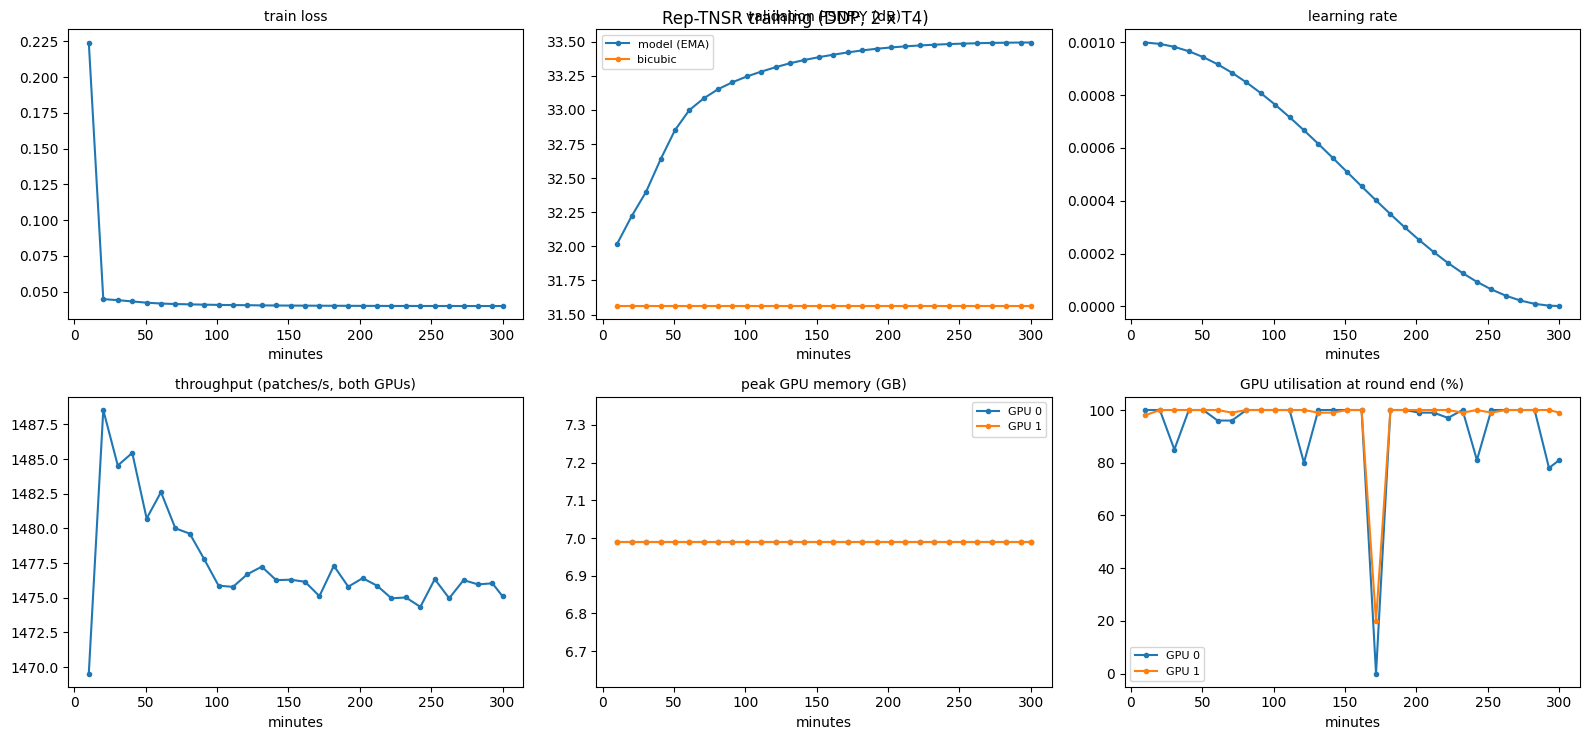

In [14]:
history_df = pd.DataFrame(
    json.loads((DIRS["metrics"] / "train_history.json").read_text())
)
history_df["val_gain_db"] = history_df["val_psnr_y"] - history_df["val_bicubic_psnr_y"]
history_df.to_csv(DIRS["metrics"] / "train_history.csv", index=False)
cols = [
    "round",
    "elapsed_min",
    "step",
    "train_loss",
    "train_psnr_rgb",
    "val_psnr_y",
    "val_ssim_y",
    "val_gain_db",
    "lr",
    "img_per_s",
]
print(history_df[cols].tail(8).round(4).to_string(index=False))
best_round = history_df.loc[history_df["val_psnr_y"].idxmax()]
print(
    f"best round {int(best_round['round'])}: val PSNR-Y {best_round['val_psnr_y']:.3f} dB, gain over bicubic {best_round['val_gain_db']:.3f} dB"
)
fig, axes = plt.subplots(2, 3, figsize=(16, 7.5))
draw_history(axes, history_df.to_dict("records"))
fig.suptitle("Rep-TNSR training (DDP, 2 x T4)")
show(fig, "training_curves")

## 15. Best weights, fusion and GPU replicas

Loads the best EMA weights, fuses every block into a plain 3x3 convolution, checks fused against unfused output on random input (CPU, FP32), saves `weights/sr_fused.pt`, and places one FP16 channels-last replica of the fused model on each GPU for the evaluation cells. Expected output: parameter counts and a parity error near 1e-6.

In [15]:
best_ckpt = torch.load(DIRS["weights"] / "sr_best_ema.pt", map_location="cpu")
model = build_model(CFG["tier"], CFG["scale"])
model.load_state_dict(best_ckpt["ema"])
model.eval()
fused = model.fused_copy()
with torch.no_grad():
    probe_input = torch.rand(4, 3, 64, 64)
    fused_parity = (model(probe_input) - fused(probe_input)).abs().max().item()
torch.save(
    {"state_dict": fused.state_dict(), "tier": CFG["tier"], "scale": CFG["scale"]},
    DIRS["weights"] / "sr_fused.pt",
)
REPLICAS = [
    copy.deepcopy(fused)
    .half()
    .to(f"cuda:{i}")
    .to(memory_format=torch.channels_last)
    .eval()
    for i in range(N_GPUS)
]
print(
    pd.Series(
        {
            "best_round": best_ckpt["round"],
            "best_val_psnr_y": round(best_ckpt["val_psnr_y"], 3),
            "train_params": count_params(model),
            "fused_params": count_params(fused),
            "fusion_parity_max_abs": f"{fused_parity:.2e}",
        }
    ).to_string()
)
assert fused_parity < 1e-4


def run_on_gpus(items, fn, desc):
    """Split items across GPUs (one thread per GPU replica) and return results in input order."""
    results = [None] * len(items)
    bar = tqdm(total=len(items), desc=desc)
    lock = threading.Lock()

    def worker(rank):
        device = torch.device("cuda", rank)
        for i in range(rank, len(items), N_GPUS):
            results[i] = fn(REPLICAS[rank], device, items[i])
            with lock:
                bar.update(1)

    with ThreadPoolExecutor(max_workers=N_GPUS) as pool:
        list(pool.map(worker, range(N_GPUS)))
    bar.close()
    return results


@torch.no_grad()
def super_resolve(net, device, hr_uint8):
    """HR uint8 (H, W, 3) -> HR, LR, bicubic and model tensors in [0, 1] on device (1, 3, H, W)."""
    hr = (
        torch.from_numpy(hr_uint8).to(device).permute(2, 0, 1)[None].float().div_(255.0)
    )
    lr = bicubic_down(hr, CFG["scale"])
    sr = quantize(net(lr.half().contiguous(memory_format=torch.channels_last)).float())
    return hr, lr, quantize(bicubic_up(lr, CFG["scale"])), sr


def image_metrics(hr, bic, sr):
    s = CFG["scale"]
    y_hr, y_bic, y_sr = rgb_to_y(hr), rgb_to_y(bic), rgb_to_y(sr)
    return {
        "psnr_y": psnr(y_sr, y_hr, s).item(),
        "ssim_y": ssim(y_sr, y_hr, s).item(),
        "psnr_rgb": psnr(sr, hr, s).item(),
        "bicubic_psnr_y": psnr(y_bic, y_hr, s).item(),
        "bicubic_ssim_y": ssim(y_bic, y_hr, s).item(),
    }

best_round                     29
best_val_psnr_y            33.495
train_params                44811
fused_params                32715
fusion_parity_max_abs    1.53e-05


## 16. Benchmark evaluation (Set5, Set14, B100, Urban100, Manga109, validation images)

Evaluates full images, split across both GPUs: each HR image is cropped to a multiple of 3, downsampled with the training degradation, super-resolved, and scored on Y with a 3-pixel border shave, next to bicubic upsampling. Up to `val_full_images` full validation images (held-out sequences of the training datasets) are included as `holdout_val`.

Note: published SR tables use MATLAB `imresize` for the LR inputs, which differs slightly from PyTorch's anti-aliased bicubic, so compare against the bicubic column here rather than against published numbers. Expected output: a per-dataset table (mean and standard deviation) and `metrics/benchmark_per_image.csv`, `metrics/benchmark_summary.csv`.

In [16]:
bench_items = catalogue[catalogue["split"] == "test"]
bench_items = bench_items[bench_items["role"] == "test"][["subset", "path"]]
holdout_items = catalogue[catalogue["split"] == "val"].sample(
    n=min(CFG["val_full_images"], int((catalogue["split"] == "val").sum())),
    random_state=CFG["seed"],
)
holdout_items = holdout_items.assign(subset="holdout_val")[["subset", "path"]]
eval_items = pd.concat([bench_items, holdout_items]).to_dict("records")


def eval_one(net, device, item):
    try:
        hr_np = load_rgb_modcrop(item["path"], CFG["scale"])
    except Exception:
        return None
    if min(hr_np.shape[:2]) < 16 * CFG["scale"]:
        return None
    hr, _, bic, sr = super_resolve(net, device, hr_np)
    return {
        "dataset": item["subset"],
        "image": Path(item["path"]).name,
        "height": hr_np.shape[0],
        "width": hr_np.shape[1],
        **image_metrics(hr, bic, sr),
    }


with stage("benchmark_eval"):
    bench_rows = [
        r
        for r in run_on_gpus(eval_items, eval_one, "Evaluating images (2 GPUs)")
        if r is not None
    ]
bench_df = pd.DataFrame(bench_rows)
bench_df["gain_psnr_y"] = bench_df["psnr_y"] - bench_df["bicubic_psnr_y"]
bench_df["gain_ssim_y"] = bench_df["ssim_y"] - bench_df["bicubic_ssim_y"]
bench_summary = (
    bench_df.groupby("dataset")
    .agg(
        images=("image", "size"),
        psnr_y=("psnr_y", "mean"),
        psnr_y_std=("psnr_y", "std"),
        ssim_y=("ssim_y", "mean"),
        bicubic_psnr_y=("bicubic_psnr_y", "mean"),
        bicubic_ssim_y=("bicubic_ssim_y", "mean"),
        gain_psnr_y=("gain_psnr_y", "mean"),
        improved_pct=("gain_psnr_y", lambda g: 100 * (g > 0).mean()),
    )
    .round(4)
)
print(bench_summary.to_string())
bench_df.to_csv(DIRS["metrics"] / "benchmark_per_image.csv", index=False)
bench_summary.to_csv(DIRS["metrics"] / "benchmark_summary.csv")

19:08:48 | start: benchmark_eval


Evaluating images (2 GPUs):   0%|          | 0/269 [00:00<?, ?it/s]

/tmp/ipykernel_23/2198529922.py:58: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  torch.from_numpy(hr_uint8).to(device).permute(2, 0, 1)[None].float().div_(255.0)


19:09:07 | done: benchmark_eval in 0.3 min (run total 5.21 h)
             images   psnr_y  psnr_y_std  ssim_y  bicubic_psnr_y  bicubic_ssim_y  gain_psnr_y  improved_pct
dataset                                                                                                    
DIV2K           100  31.3263      4.9166  0.8696         29.8046          0.8342       1.5217         100.0
Set14            14  29.4595      3.7600  0.8259         27.7943          0.7809       1.6652         100.0
Set5              5  32.9284      3.1858  0.9133         30.6357          0.8719       2.2926         100.0
holdout_val     150  35.9249      6.1155  0.9360         33.3110          0.9088       2.6139         100.0


## 17. Benchmark plots and error analysis

Bar chart of model against bicubic PSNR-Y per dataset; box plots of the per-image gain; a scatter of gain against bicubic PSNR-Y (low bicubic PSNR means a hard, detailed image); and the five images with the largest and smallest gains. Expected output: gains above zero for nearly every image, largest on structured content such as Urban100 and Manga109.

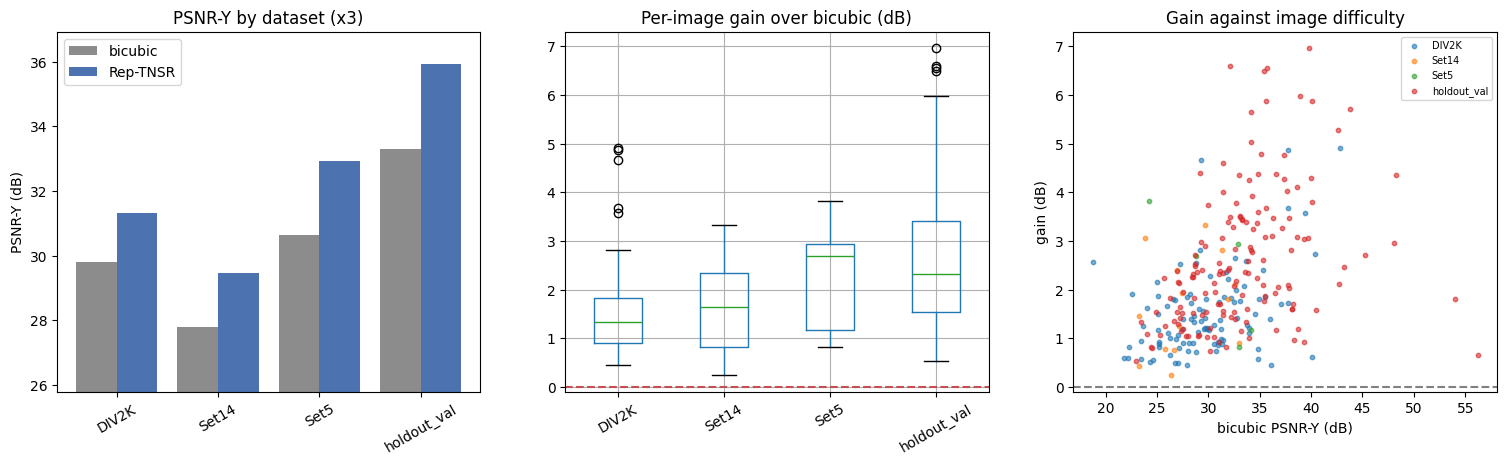

largest gains:
    dataset   image  psnr_y  bicubic_psnr_y  gain_psnr_y
holdout_val im6.png  46.714          39.754        6.961
holdout_val im4.png  38.726          32.139        6.587
holdout_val im3.png  42.285          35.738        6.547
holdout_val im4.png  41.916          35.434        6.482
holdout_val im1.png  44.884          38.910        5.975
smallest gains:
dataset       image  psnr_y  bicubic_psnr_y  gain_psnr_y
  Set14 barbara.png  26.585          26.347        0.238
  Set14  baboon.png  23.704          23.263        0.440
  DIV2K    0857.png  36.582          36.138        0.444
  DIV2K    0829.png  28.430          27.971        0.460
  DIV2K    0866.png  27.538          27.044        0.494


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
order = bench_summary.index.tolist()
x = np.arange(len(order))
axes[0].bar(
    x - 0.2, bench_summary["bicubic_psnr_y"], 0.4, label="bicubic", color="#8C8C8C"
)
axes[0].bar(x + 0.2, bench_summary["psnr_y"], 0.4, label="Rep-TNSR", color="#4C72B0")
axes[0].set_xticks(x, order, rotation=30)
axes[0].set_ylim(
    bench_summary["bicubic_psnr_y"].min() - 2, bench_summary["psnr_y"].max() + 1
)
axes[0].set_ylabel("PSNR-Y (dB)")
axes[0].legend()
axes[0].set_title("PSNR-Y by dataset (x3)")
bench_df.boxplot(column="gain_psnr_y", by="dataset", ax=axes[1], rot=30)
axes[1].axhline(0, ls="--", color="#C44E52")
axes[1].set_title("Per-image gain over bicubic (dB)")
axes[1].set_xlabel("")
for name, group in bench_df.groupby("dataset"):
    axes[2].scatter(
        group["bicubic_psnr_y"], group["gain_psnr_y"], s=10, alpha=0.6, label=name
    )
axes[2].axhline(0, ls="--", color="grey")
axes[2].set_xlabel("bicubic PSNR-Y (dB)")
axes[2].set_ylabel("gain (dB)")
axes[2].set_title("Gain against image difficulty")
axes[2].legend(fontsize=7)
fig.suptitle("")
show(fig, "benchmark_results")
show_cols = ["dataset", "image", "psnr_y", "bicubic_psnr_y", "gain_psnr_y"]
print(
    "largest gains:\n"
    + bench_df.nlargest(5, "gain_psnr_y")[show_cols].round(3).to_string(index=False)
)
print(
    "smallest gains:\n"
    + bench_df.nsmallest(5, "gain_psnr_y")[show_cols].round(3).to_string(index=False)
)

## 18. Visual comparisons

For one median-gain image per benchmark dataset, shows the LR input (nearest-neighbour enlarged), bicubic, Rep-TNSR and HR crops of 128 px, plus the model's absolute error map. Each crop is centred where the model's improvement over bicubic is largest. Super-resolved full images are saved to `predictions/`. Expected output: sharper edges and text than bicubic, with error concentrated on fine texture.

Rendering comparisons:   0%|          | 0/3 [00:00<?, ?it/s]

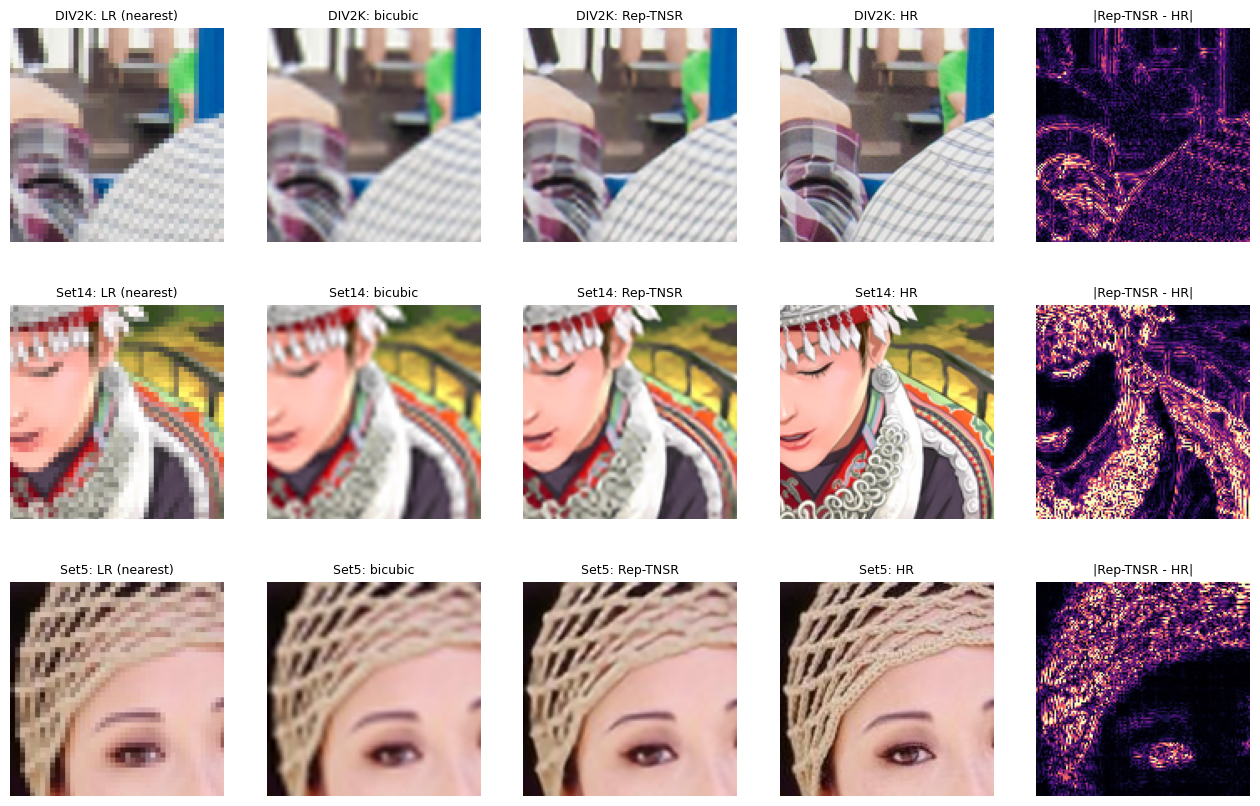

In [18]:
picks = []
for name, group in bench_df[bench_df["dataset"] != "holdout_val"].groupby("dataset"):
    median_row = group.iloc[
        (group["gain_psnr_y"] - group["gain_psnr_y"].median()).abs().argmin()
    ]
    path = bench_items[
        (bench_items["subset"] == name)
        & (bench_items["path"].map(lambda p: Path(p).name) == median_row["image"])
    ]["path"].iloc[0]
    picks.append((name, path))


def to_np(t):
    return t[0].permute(1, 2, 0).float().cpu().numpy()


fig, axes = plt.subplots(
    max(1, len(picks)), 5, figsize=(16, 3.4 * max(1, len(picks))), squeeze=False
)
for row_axes, (name, path) in zip(axes, tqdm(picks, desc="Rendering comparisons")):
    hr, lr, bic, sr = super_resolve(
        REPLICAS[0], torch.device("cuda", 0), load_rgb_modcrop(path, CFG["scale"])
    )
    crop = min(128, *hr.shape[-2:])
    gain_map = (rgb_to_y(bic) - rgb_to_y(hr)).abs() - (
        rgb_to_y(sr) - rgb_to_y(hr)
    ).abs()
    gain_map = F.avg_pool2d(gain_map, crop, stride=8)
    gy, gx = np.unravel_index(gain_map[0, 0].argmax().item(), gain_map.shape[-2:])
    y0, x0 = gy * 8, gx * 8
    lr_big = F.interpolate(lr, scale_factor=CFG["scale"], mode="nearest")
    panels = [
        ("LR (nearest)", to_np(lr_big)),
        ("bicubic", to_np(bic)),
        ("Rep-TNSR", to_np(sr)),
        ("HR", to_np(hr)),
    ]
    for ax, (title, img) in zip(row_axes, panels):
        ax.imshow(np.clip(img[y0 : y0 + crop, x0 : x0 + crop], 0, 1))
        ax.set_title(f"{name}: {title}", fontsize=9)
        ax.axis("off")
    err = np.abs(to_np(sr) - to_np(hr)).mean(axis=2)[y0 : y0 + crop, x0 : x0 + crop]
    row_axes[4].imshow(err, cmap="magma", vmin=0, vmax=0.15)
    row_axes[4].set_title("|Rep-TNSR - HR|", fontsize=9)
    row_axes[4].axis("off")
    Image.fromarray((to_np(sr) * 255).round().astype(np.uint8)).save(
        DIRS["predictions"] / f"{name}_{Path(path).stem}_x{CFG['scale']}.png"
    )
show(fig, "visual_comparisons")

## 19. Vid4 video evaluation and temporal stability

Each Vid4 sequence is processed frame by frame (sequences split across both GPUs). Besides per-frame PSNR-Y and SSIM-Y, it reports a flow-free temporal error: the mean absolute difference between the output's frame-to-frame change and the ground truth's frame-to-frame change on Y (lower means less flicker relative to the real motion). RAFT-based tOF needs downloaded weights and is left to the workstation evaluation in `RESEARCH.md`. Expected output: a per-sequence table, per-frame PSNR curves and `metrics/vid4_*.csv`.

19:09:11 | start: vid4_eval


Vid4 sequences (2 GPUs):   0%|          | 0/4 [00:00<?, ?it/s]

19:09:16 | done: vid4_eval in 0.1 min (run total 5.21 h)
          frames    psnr_y   ssim_y  bicubic_psnr_y  temporal_err_model  temporal_err_bicubic
sequence                                                                                     
calendar   41.00  22.91791  0.75751        21.76587             0.04214               0.04641
city       34.00  26.85883  0.75529        26.25783             0.03533               0.03795
foliage    49.00  26.37920  0.77239        25.29436             0.04239               0.04579
walk       47.00  30.44089  0.91110        28.40401             0.01594               0.01989
mean       42.75  26.64921  0.79907        25.43052             0.03395               0.03751


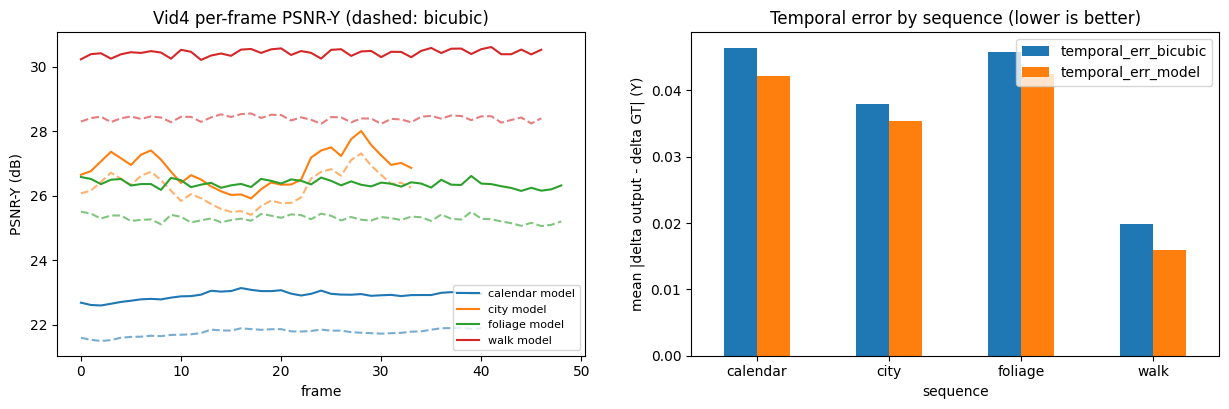

In [19]:
vid4 = catalogue[catalogue["role"] == "video_test"].copy()
vid4["sequence"] = vid4["path"].map(sequence_name)
sequences = [
    {"sequence": s, "frames": sorted(g["path"].tolist())}
    for s, g in vid4.groupby("sequence")
]


def eval_sequence(net, device, item):
    rows, prev = [], None
    for idx, path in enumerate(item["frames"]):
        hr, _, bic, sr = super_resolve(
            net, device, load_rgb_modcrop(path, CFG["scale"])
        )
        y = {k: rgb_to_y(v) for k, v in (("hr", hr), ("bic", bic), ("sr", sr))}
        row = {"sequence": item["sequence"], "frame": idx, **image_metrics(hr, bic, sr)}
        if prev is not None and prev["hr"].shape == y["hr"].shape:
            gt_delta = y["hr"] - prev["hr"]
            row["temporal_err_model"] = (
                ((y["sr"] - prev["sr"]) - gt_delta).abs().mean().item()
            )
            row["temporal_err_bicubic"] = (
                ((y["bic"] - prev["bic"]) - gt_delta).abs().mean().item()
            )
        rows.append(row)
        prev = y
    return rows


if sequences:
    with stage("vid4_eval"):
        vid4_df = pd.DataFrame(
            [
                r
                for rows in run_on_gpus(
                    sequences, eval_sequence, "Vid4 sequences (2 GPUs)"
                )
                for r in rows
            ]
        )
    vid4_summary = vid4_df.groupby("sequence").agg(
        frames=("frame", "size"),
        psnr_y=("psnr_y", "mean"),
        ssim_y=("ssim_y", "mean"),
        bicubic_psnr_y=("bicubic_psnr_y", "mean"),
        temporal_err_model=("temporal_err_model", "mean"),
        temporal_err_bicubic=("temporal_err_bicubic", "mean"),
    )
    vid4_summary.loc["mean"] = vid4_summary.mean(numeric_only=True)
    print(vid4_summary.round(5).to_string())
    vid4_df.to_csv(DIRS["metrics"] / "vid4_per_frame.csv", index=False)
    vid4_summary.to_csv(DIRS["metrics"] / "vid4_summary.csv")
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.2))
    for name, group in vid4_df.groupby("sequence"):
        (line,) = axes[0].plot(group["frame"], group["psnr_y"], label=f"{name} model")
        axes[0].plot(
            group["frame"],
            group["bicubic_psnr_y"],
            ls="--",
            color=line.get_color(),
            alpha=0.6,
        )
    axes[0].set_xlabel("frame")
    axes[0].set_ylabel("PSNR-Y (dB)")
    axes[0].set_title("Vid4 per-frame PSNR-Y (dashed: bicubic)")
    axes[0].legend(fontsize=8)
    vid4_summary.drop(index="mean")[
        ["temporal_err_bicubic", "temporal_err_model"]
    ].plot.bar(ax=axes[1], rot=0)
    axes[1].set_ylabel("mean |delta output - delta GT| (Y)")
    axes[1].set_title("Temporal error by sequence (lower is better)")
    show(fig, "vid4_results")
else:
    vid4_summary = None
    log.warning("Vid4 not attached; video evaluation skipped")

## 20. Inference latency

Times the fused FP16 model on GPU 0 with CUDA events (warm-up, then `latency_iters` timed runs) for 640x360 to 1920x1080 and 1280x720 to 3840x2160, and the unfused training graph at 640x360 for comparison. This is a T4 measurement through PyTorch, not the DirectML or HLSL deployment path, so it ranks variants rather than predicting in-engine latency. Expected output: mean, P50 and P95 latency, frames per second, peak memory, and a latency histogram.

19:09:17 | start: latency


Timing 640x360:   0%|          | 0/200 [00:00<?, ?it/s]

Timing 1280x720:   0%|          | 0/200 [00:00<?, ?it/s]

Timing 640x360:   0%|          | 0/200 [00:00<?, ?it/s]

19:09:28 | done: latency in 0.2 min (run total 5.22 h)
        variant  mean_ms  p50_ms  p95_ms     fps  peak_mem_mib
  fused 640x360    4.224   4.126   4.778 236.721        51.582
 fused 1280x720   16.766  16.814  17.115  59.645       195.312
unfused 640x360   30.333  30.252  31.068  32.968       142.780


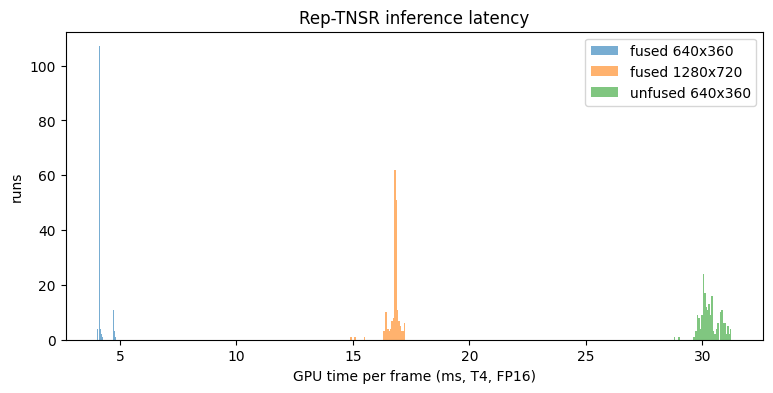

In [20]:
@torch.no_grad()
def time_model(net, size, iters):
    device = torch.device("cuda", 0)
    x = (
        torch.rand(1, 3, *size, device=device)
        .half()
        .contiguous(memory_format=torch.channels_last)
    )
    for _ in range(20):
        net(x)
    torch.cuda.synchronize(device)
    torch.cuda.reset_peak_memory_stats(device)
    times = []
    for _ in tqdm(range(iters), desc=f"Timing {size[1]}x{size[0]}", leave=False):
        start, end = torch.cuda.Event(enable_timing=True), torch.cuda.Event(
            enable_timing=True
        )
        start.record()
        net(x)
        end.record()
        torch.cuda.synchronize(device)
        times.append(start.elapsed_time(end))
    return np.array(times), torch.cuda.max_memory_allocated(device) / 2**20


with stage("latency"):
    unfused_fp16 = (
        copy.deepcopy(model)
        .half()
        .to("cuda:0")
        .to(memory_format=torch.channels_last)
        .eval()
    )
    variants = [
        (f"fused {w}x{h}", REPLICAS[0], (h, w)) for h, w in CFG["latency_sizes"]
    ]
    variants.append(
        (
            f"unfused {CFG['latency_sizes'][0][1]}x{CFG['latency_sizes'][0][0]}",
            unfused_fp16,
            tuple(CFG["latency_sizes"][0]),
        )
    )
    latency_rows, latency_samples = [], {}
    for name, net, size in variants:
        times, peak_mib = time_model(net, size, CFG["latency_iters"])
        latency_samples[name] = times
        latency_rows.append(
            {
                "variant": name,
                "mean_ms": times.mean(),
                "p50_ms": np.median(times),
                "p95_ms": np.percentile(times, 95),
                "fps": 1000 / times.mean(),
                "peak_mem_mib": peak_mib,
            }
        )
    del unfused_fp16
latency_df = pd.DataFrame(latency_rows).round(3)
print(latency_df.to_string(index=False))
latency_df.to_csv(DIRS["metrics"] / "latency.csv", index=False)
fig, ax = plt.subplots(figsize=(9, 4))
for name, times in latency_samples.items():
    ax.hist(times, bins=40, alpha=0.6, label=name)
ax.set_xlabel("GPU time per frame (ms, T4, FP16)")
ax.set_ylabel("runs")
ax.legend()
ax.set_title("Rep-TNSR inference latency")
show(fig, "latency")

## 21. ONNX export

Exports the fused FP32 model to `weights/rep_tnsr_fused.onnx` (opset 17, dynamic batch, height and width), trying the TorchScript exporter first and the default exporter second, then checks it with ONNX Runtime when that package is present. Failures are reported, not raised, because the trained weights are already saved. Expected output: a status table and the ONNX-versus-PyTorch difference.

In [21]:
with stage("onnx_export"):
    onnx_path = DIRS["weights"] / "rep_tnsr_fused.onnx"
    cpu_fused = copy.deepcopy(fused).float().cpu().eval()
    dummy = torch.rand(1, 3, 64, 64)
    export_status = {"exported": False, "error": None, "onnxruntime_max_abs_diff": None}
    for kwargs in ({"dynamo": False}, {}):
        try:
            torch.onnx.export(
                cpu_fused,
                dummy,
                str(onnx_path),
                input_names=["lr"],
                output_names=["sr"],
                opset_version=17,
                dynamic_axes={
                    "lr": {0: "n", 2: "h", 3: "w"},
                    "sr": {0: "n", 2: "H", 3: "W"},
                },
                **kwargs,
            )
            export_status.update(exported=True, error=None)
            break
        except Exception as exc:
            export_status["error"] = repr(exc)[:300]
    if export_status["exported"]:
        try:
            import onnxruntime as ort

            session = ort.InferenceSession(
                str(onnx_path), providers=["CPUExecutionProvider"]
            )
            test_in = torch.rand(1, 3, 90, 160)
            onnx_out = session.run(None, {"lr": test_in.numpy()})[0]
            with torch.no_grad():
                export_status["onnxruntime_max_abs_diff"] = float(
                    np.abs(onnx_out - cpu_fused(test_in).numpy()).max()
                )
        except Exception as exc:
            export_status["onnxruntime_check"] = f"skipped: {exc!r}"[:200]
        export_status["onnx_mb"] = round(onnx_path.stat().st_size / 2**20, 3)
print(pd.Series(export_status).to_string())
save_json(export_status, "onnx_export.json")

19:09:29 | start: onnx_export


/tmp/ipykernel_23/1903223561.py:8: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


19:09:30 | done: onnx_export in 0.0 min (run total 5.22 h)
exported                                                                 True
error                                                                    None
onnxruntime_max_abs_diff                                                 None
onnxruntime_check           skipped: ModuleNotFoundError("No module named ...
onnx_mb                                                                 0.131


## 22. Summary

Collects the key results into one table (`metrics/summary.json`) and reports the run time of every stage against the 8 hour budget (`metrics/stage_times.csv`, bar chart). Expected output: the summary table, the stage table and a total below 8 hours.

model                             Rep-TNSR ultra x3 (RGB)
fused_params                                        32715
train_minutes                                       300.3
train_steps                                         25880
batch_per_gpu                                         512
effective_batch                                      1024
mean_throughput_patches_s                          1477.4
peak_mem_gb_per_gpu                          [6.99, 6.99]
best_val_psnr_y                                    33.495
best_val_gain_db                                    1.932
DIV2K_psnr_y                                      31.3263
DIV2K_gain_db                                      1.5217
Set14_psnr_y                                      29.4595
Set14_gain_db                                      1.6652
Set5_psnr_y                                       32.9284
Set5_gain_db                                       2.2926
holdout_val_psnr_y                                35.9249
holdout_val_ga

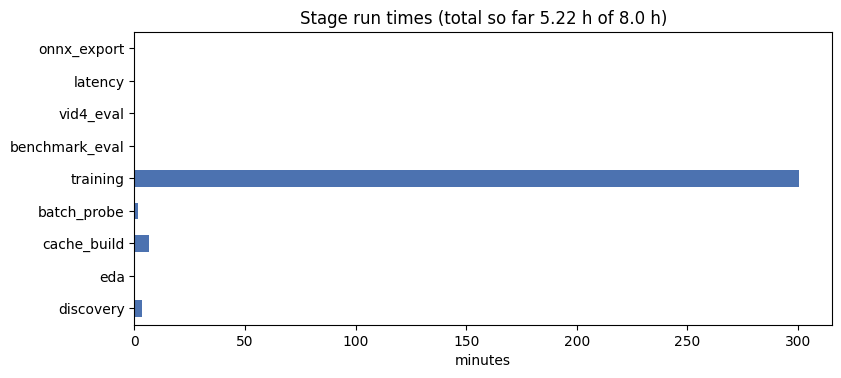

In [22]:
summary = {
    "model": f"Rep-TNSR {CFG['tier']} x{CFG['scale']} (RGB)",
    "fused_params": count_params(fused),
    "train_minutes": round(STAGE_TIMES.get("training", 0) / 60, 1),
    "train_steps": done_info.get("steps"),
    "batch_per_gpu": BATCH_PER_GPU,
    "effective_batch": EFFECTIVE_BATCH,
    "mean_throughput_patches_s": round(history_df["img_per_s"].mean(), 1),
    "peak_mem_gb_per_gpu": history_df["mem_gb"].iloc[-1],
    "best_val_psnr_y": round(best_round["val_psnr_y"], 3),
    "best_val_gain_db": round(best_round["val_gain_db"], 3),
}
for name, row in bench_summary.iterrows():
    summary[f"{name}_psnr_y"] = row["psnr_y"]
    summary[f"{name}_gain_db"] = row["gain_psnr_y"]
if vid4_summary is not None:
    summary["vid4_psnr_y"] = round(vid4_summary.loc["mean", "psnr_y"], 3)
    summary["vid4_temporal_err_model"] = round(
        vid4_summary.loc["mean", "temporal_err_model"], 5
    )
    summary["vid4_temporal_err_bicubic"] = round(
        vid4_summary.loc["mean", "temporal_err_bicubic"], 5
    )
for _, row in latency_df.iterrows():
    summary[f"latency_p95_ms_{row['variant'].replace(' ', '_')}"] = row["p95_ms"]
summary["onnx_exported"] = export_status["exported"]
summary["run_hours_so_far"] = round((time.time() - NOTEBOOK_START) / 3600, 2)
print(pd.Series(summary).to_string())
save_json(summary, "summary.json")

stage_df = pd.Series(STAGE_TIMES, name="seconds").to_frame()
stage_df["minutes"] = (stage_df["seconds"] / 60).round(1)
stage_df.to_csv(DIRS["metrics"] / "stage_times.csv")
print(stage_df.to_string())
fig, ax = plt.subplots(figsize=(9, 3.8))
stage_df["minutes"].plot.barh(ax=ax, color="#4C72B0")
ax.set_xlabel("minutes")
ax.set_title(
    f"Stage run times (total so far {summary['run_hours_so_far']} h of {RUN_BUDGET_H} h)"
)
show(fig, "stage_times")

## 23. Remove the temporary patch cache

The cache is an intermediate, not an output: deleting it keeps the saved Kaggle output small and frees disk for the zip. Expected output: the space freed.

In [23]:
cache_bytes = sum(p.stat().st_size for p in DIRS["cache"].rglob("*") if p.is_file())
shutil.rmtree(DIRS["cache"], ignore_errors=True)
print(f"removed cache: {cache_bytes / 1e9:.2f} GB freed")

removed cache: 7.35 GB freed


## 24. Package outputs

Zips everything in `/kaggle/working` (weights, plots, metrics, logs, predictions, code) into `outputs.zip`, storing already-compressed files without recompression, after checking there is enough disk. The link below downloads it; after a **Save & Run All** version, the zip and all files also appear in the notebook's **Output** tab.

In [24]:
with stage("packaging"):
    ZIP_PATH = WORK / "outputs.zip"
    EXCLUDE_PARTS = {
        "__pycache__",
        ".cache",
        ".ipynb_checkpoints",
        "cache",
        "tmp",
        "wandb",
    }
    STORED_SUFFIXES = {
        ".zip",
        ".png",
        ".jpg",
        ".jpeg",
        ".pt",
        ".pth",
        ".bin",
        ".safetensors",
        ".gz",
        ".npz",
        ".onnx",
    }
    files = [
        path
        for path in WORK.rglob("*")
        if path.is_file()
        and path != ZIP_PATH
        and not EXCLUDE_PARTS.intersection(path.relative_to(WORK).parts)
    ]
    total_bytes = sum(path.stat().st_size for path in files)
    free_bytes = shutil.disk_usage(WORK).free
    assert (
        free_bytes > total_bytes * 1.05
    ), f"Not enough disk space to zip {total_bytes / 1e9:.2f} GB with {free_bytes / 1e9:.2f} GB free."
    with zipfile.ZipFile(ZIP_PATH, "w", allowZip64=True) as archive:
        for path in tqdm(files, desc="Zipping outputs", unit="file"):
            method = (
                zipfile.ZIP_STORED
                if path.suffix.lower() in STORED_SUFFIXES
                else zipfile.ZIP_DEFLATED
            )
            archive.write(path, path.relative_to(WORK), compress_type=method)
print(
    f"Zipped {len(files)} files ({total_bytes / 1e9:.2f} GB) into {ZIP_PATH}; total run time {(time.time() - NOTEBOOK_START) / 3600:.2f} h",
    flush=True,
)
display(FileLink(os.path.relpath(ZIP_PATH)))

19:09:31 | start: packaging


Zipping outputs:   0%|          | 0/47 [00:00<?, ?file/s]

19:09:31 | done: packaging in 0.0 min (run total 5.22 h)
Zipped 47 files (0.03 GB) into /kaggle/working/outputs.zip; total run time 5.22 h


/kaggle/working/outputs.zip